[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/syriascitech/Medad-CV-Bootcamp/blob/main/Week6/week_6_yolo_object_detection_CV.ipynb)

<style>
.rtl-cell {
    direction: rtl !important;
    text-align: right !important;
    line-height: 1.9 !important;
    font-size: 17px !important;
    font-family: Arial, Tahoma, sans-serif !important;
}
.rtl-cell p,
.rtl-cell h1,
.rtl-cell h2,
.rtl-cell h3,
.rtl-cell h4,
.rtl-cell h5,
.rtl-cell h6,
.rtl-cell li,
.rtl-cell blockquote,
.rtl-cell th,
.rtl-cell td {
    direction: rtl !important;
    text-align: right !important;
}
.rtl-cell ul,
.rtl-cell ol {
    direction: rtl !important;
    text-align: right !important;
    padding-right: 2em !important;
    padding-left: 0 !important;
}
.rtl-cell blockquote {
    border-right: 4px solid #d0d7de !important;
    border-left: none !important;
    margin-right: 0 !important;
    padding-right: 1em !important;
}
.rtl-cell table {
    direction: rtl !important;
    text-align: right !important;
    margin-right: 0 !important;
    margin-left: auto !important;
    border-collapse: collapse !important;
}
.rtl-cell th,
.rtl-cell td {
    padding: 7px 10px !important;
}
.rtl-cell code {
    direction: ltr !important;
    unicode-bidi: isolate !important;
}
.rtl-cell pre,
.rtl-cell pre code {
    direction: ltr !important;
    text-align: left !important;
    unicode-bidi: embed !important;
}
.rtl-cell .ltr,
.rtl-cell [dir="ltr"] {
    direction: ltr !important;
    text-align: left !important;
}
</style>

<div class="rtl-cell" dir="rtl" style="direction:rtl !important; text-align:right !important;">
<h1>الأسبوع 6: كشف الأجسام باستخدام YOLO</h1>
<h2>Object Detection with YOLO</h2>
<hr />
<p><strong>مسار أنظمة المرور الذكية – الرؤية الحاسوبية</strong></p>
<p><strong>المُعد/المؤلف:</strong> محمد أمهان</p>
<hr />
<p>في الأسبوع السابق تعلّمنا كيف تستخرج الشبكات الالتفافية <strong>CNN</strong> الميزات من الصور وكيف تستخدمها للتصنيف.</p>
<p>لكن التصنيف يجيب عن سؤال واحد فقط:</p>
<blockquote>
<p><strong>ما الموجود في الصورة؟</strong></p>
</blockquote>
<p>أما في أنظمة المرور فنحتاج إجابة أكثر تفصيلاً:</p>
<blockquote>
<p><strong>ما الأجسام الموجودة؟ وأين يقع كل جسم داخل الصورة؟</strong></p>
</blockquote>
<p>وهنا ننتقل من <strong>Image Classification</strong> إلى <strong>Object Detection</strong>.</p>
<p>في هذا الأسبوع سنستخدم نموذج YOLO جاهزاً لاكتشاف السيارات والمشاة في الصور والفيديو، من دون تدريب نموذج جديد.<br />
تجهيز البيانات والتدريب وFine-tuning سيكون موضوع الأسبوع 7.</p>
<div style="text-align:center; margin:24px 0;">
<img
src="https://raw.githubusercontent.com/syriascitech/Medad-CV-Bootcamp/main/Week6/media/object_detection_example.jpg"
alt="Object Detection Example"
width="900">
</div>

</div>

<style>
.rtl-cell {
    direction: rtl !important;
    text-align: right !important;
    line-height: 1.9 !important;
    font-size: 17px !important;
    font-family: Arial, Tahoma, sans-serif !important;
}
.rtl-cell p,
.rtl-cell h1,
.rtl-cell h2,
.rtl-cell h3,
.rtl-cell h4,
.rtl-cell h5,
.rtl-cell h6,
.rtl-cell li,
.rtl-cell blockquote,
.rtl-cell th,
.rtl-cell td {
    direction: rtl !important;
    text-align: right !important;
}
.rtl-cell ul,
.rtl-cell ol {
    direction: rtl !important;
    text-align: right !important;
    padding-right: 2em !important;
    padding-left: 0 !important;
}
.rtl-cell blockquote {
    border-right: 4px solid #d0d7de !important;
    border-left: none !important;
    margin-right: 0 !important;
    padding-right: 1em !important;
}
.rtl-cell table {
    direction: rtl !important;
    text-align: right !important;
    margin-right: 0 !important;
    margin-left: auto !important;
    border-collapse: collapse !important;
}
.rtl-cell th,
.rtl-cell td {
    padding: 7px 10px !important;
}
.rtl-cell code {
    direction: ltr !important;
    unicode-bidi: isolate !important;
}
.rtl-cell pre,
.rtl-cell pre code {
    direction: ltr !important;
    text-align: left !important;
    unicode-bidi: embed !important;
}
.rtl-cell .ltr,
.rtl-cell [dir="ltr"] {
    direction: ltr !important;
    text-align: left !important;
}
</style>

<div class="rtl-cell" dir="rtl" style="direction:rtl !important; text-align:right !important;">
<h2>أهداف الدرس</h2>
<p>بنهاية هذا الدرس سيكون الطالب قادراً على:</p>
<ol>
<li>التمييز بين <strong>Image Classification</strong> و <strong>Object Detection</strong>.</li>
<li>فهم مخرجات نموذج الكشف:<br />
<strong>Bounding Box – Class – Confidence</strong>.</li>
<li>شرح بنية YOLO بالمستوى العام:<br />
<strong>Backbone → Neck → Detection Head</strong>.</li>
<li>تحميل نموذج YOLO جاهز واستخدامه على صورة.</li>
<li>قراءة نتائج النموذج برمجياً.</li>
<li>فلترة النتائج لاكتشاف المركبات والمشاة فقط.</li>
<li>تطبيق الكشف على فيديو مروري قصير.</li>
<li>فهم الفرق بين <strong>Detection</strong> و <strong>Tracking</strong>.</li>
</ol>
</div>

<style>
.rtl-cell {
    direction: rtl !important;
    text-align: right !important;
    line-height: 1.9 !important;
    font-size: 17px !important;
    font-family: Arial, Tahoma, sans-serif !important;
}
.rtl-cell p,
.rtl-cell h1,
.rtl-cell h2,
.rtl-cell h3,
.rtl-cell h4,
.rtl-cell h5,
.rtl-cell h6,
.rtl-cell li,
.rtl-cell blockquote,
.rtl-cell th,
.rtl-cell td {
    direction: rtl !important;
    text-align: right !important;
}
.rtl-cell ul,
.rtl-cell ol {
    direction: rtl !important;
    text-align: right !important;
    padding-right: 2em !important;
    padding-left: 0 !important;
}
.rtl-cell blockquote {
    border-right: 4px solid #d0d7de !important;
    border-left: none !important;
    margin-right: 0 !important;
    padding-right: 1em !important;
}
.rtl-cell table {
    direction: rtl !important;
    text-align: right !important;
    margin-right: 0 !important;
    margin-left: auto !important;
    border-collapse: collapse !important;
}
.rtl-cell th,
.rtl-cell td {
    padding: 7px 10px !important;
}
.rtl-cell code {
    direction: ltr !important;
    unicode-bidi: isolate !important;
}
.rtl-cell pre,
.rtl-cell pre code {
    direction: ltr !important;
    text-align: left !important;
    unicode-bidi: embed !important;
}
.rtl-cell .ltr,
.rtl-cell [dir="ltr"] {
    direction: ltr !important;
    text-align: left !important;
}
</style>

<div class="rtl-cell" dir="rtl" style="direction:rtl !important; text-align:right !important;">
<h2>محتويات الدرس</h2>
<ol>
<li>من تصنيف الصور إلى كشف الأجسام</li>
<li>مخرجات نموذج Object Detection</li>
<li>الفكرة الأساسية خلف YOLO</li>
<li>بنية YOLO: Backbone, Neck, Head</li>
<li>النماذج المدربة Pretrained Models</li>
<li>تشغيل أول نموذج YOLO</li>
<li>قراءة الـ Bounding Boxes والثقة والفئات</li>
<li>كشف السيارات والمشاة فقط</li>
<li>تأثير Confidence Threshold</li>
<li>كشف الأجسام في فيديو</li>
<li>Detection مقابل Tracking</li>
<li>تمارين وتحديات</li>
</ol>
</div>

In [1]:
!pip install -q ultralytics imageio pandas

print("✅ تم تثبيت المكتبات المطلوبة")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.1/46.1 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 60.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 6.1 MB/s eta 0:00:00
✅ تم تثبيت المكتبات المطلوبة


In [2]:
import cv2
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import imageio.v2 as imageio

from collections import Counter
from pathlib import Path
from IPython.display import display, Video
from IPython.display import Image as IPImage
from ultralytics import YOLO, ASSETS

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
PyTorch version: 2.11.0+cpu
CUDA available: False


<style>
.rtl-cell {
    direction: rtl !important;
    text-align: right !important;
    line-height: 1.9 !important;
    font-size: 17px !important;
    font-family: Arial, Tahoma, sans-serif !important;
}
.rtl-cell p,
.rtl-cell h1,
.rtl-cell h2,
.rtl-cell h3,
.rtl-cell h4,
.rtl-cell h5,
.rtl-cell h6,
.rtl-cell li,
.rtl-cell blockquote,
.rtl-cell th,
.rtl-cell td {
    direction: rtl !important;
    text-align: right !important;
}
.rtl-cell ul,
.rtl-cell ol {
    direction: rtl !important;
    text-align: right !important;
    padding-right: 2em !important;
    padding-left: 0 !important;
}
.rtl-cell blockquote {
    border-right: 4px solid #d0d7de !important;
    border-left: none !important;
    margin-right: 0 !important;
    padding-right: 1em !important;
}
.rtl-cell table {
    direction: rtl !important;
    text-align: right !important;
    margin-right: 0 !important;
    margin-left: auto !important;
    border-collapse: collapse !important;
}
.rtl-cell th,
.rtl-cell td {
    padding: 7px 10px !important;
}
.rtl-cell code {
    direction: ltr !important;
    unicode-bidi: isolate !important;
}
.rtl-cell pre,
.rtl-cell pre code {
    direction: ltr !important;
    text-align: left !important;
    unicode-bidi: embed !important;
}
.rtl-cell .ltr,
.rtl-cell [dir="ltr"] {
    direction: ltr !important;
    text-align: left !important;
}
</style>

<div class="rtl-cell" dir="rtl" style="direction:rtl !important; text-align:right !important;">
<h2>اختيار الجهاز Device</h2>
<ul>
<li>إذا كانت GPU متاحة فسنستخدمها.</li>
<li>وإلا سيعمل النموذج على CPU، لكن معالجة الفيديو ستكون أبطأ.</li>
</ul>
</div>

In [3]:
DEVICE = 0 if torch.cuda.is_available() else "cpu"
print("الجهاز المستخدم:", DEVICE)

الجهاز المستخدم: cpu


<style>
.rtl-cell {
    direction: rtl !important;
    text-align: right !important;
    line-height: 1.9 !important;
    font-size: 17px !important;
    font-family: Arial, Tahoma, sans-serif !important;
}
.rtl-cell p,
.rtl-cell h1,
.rtl-cell h2,
.rtl-cell h3,
.rtl-cell h4,
.rtl-cell h5,
.rtl-cell h6,
.rtl-cell li,
.rtl-cell blockquote,
.rtl-cell th,
.rtl-cell td {
    direction: rtl !important;
    text-align: right !important;
}
.rtl-cell ul,
.rtl-cell ol {
    direction: rtl !important;
    text-align: right !important;
    padding-right: 2em !important;
    padding-left: 0 !important;
}
.rtl-cell blockquote {
    border-right: 4px solid #d0d7de !important;
    border-left: none !important;
    margin-right: 0 !important;
    padding-right: 1em !important;
}
.rtl-cell table {
    direction: rtl !important;
    text-align: right !important;
    margin-right: 0 !important;
    margin-left: auto !important;
    border-collapse: collapse !important;
}
.rtl-cell th,
.rtl-cell td {
    padding: 7px 10px !important;
}
.rtl-cell code {
    direction: ltr !important;
    unicode-bidi: isolate !important;
}
.rtl-cell pre,
.rtl-cell pre code {
    direction: ltr !important;
    text-align: left !important;
    unicode-bidi: embed !important;
}
.rtl-cell .ltr,
.rtl-cell [dir="ltr"] {
    direction: ltr !important;
    text-align: left !important;
}
</style>

<div class="rtl-cell" dir="rtl" style="direction:rtl !important; text-align:right !important;">
<hr />
<h1>1. من Image Classification إلى Object Detection</h1>
<table>
<thead>
<tr>
  <th>المهمة</th>
  <th>السؤال الذي تجيب عنه</th>
  <th>النتيجة</th>
</tr>
</thead>
<tbody>
<tr>
  <td><strong>Image Classification</strong></td>
  <td>ما الفئة الرئيسية الموجودة في الصورة؟</td>
  <td>فئة واحدة مثل <code>car</code></td>
</tr>
<tr>
  <td><strong>Object Detection</strong></td>
  <td>ما الأجسام الموجودة وأين تقع؟</td>
  <td>عدة أجسام، ولكل جسم فئة ومربع وثقة</td>
</tr>
<tr>
  <td><strong>Object Tracking</strong></td>
  <td>أين تحرك كل جسم عبر الزمن؟</td>
  <td>كشف + رقم ID ثابت عبر الإطارات</td>
</tr>
</tbody>
</table>
<h3>مثال</h3>
<p>إذا احتوت الصورة على ثلاث سيارات وشخصين:</p>
<ul>
<li>نموذج <strong>Classification</strong> قد يقول: <code>street</code></li>
<li>نموذج <strong>Object Detection</strong> يرسم 5 مربعات ويحدد نوع كل جسم</li>
<li>نموذج <strong>Object Tracking</strong> يعطي كل جسم رقماً مثل <code>Car ID 7</code></li>
</ul>
<blockquote>
<p>في هذا الأسبوع سننفذ <strong>Detection فقط</strong>.<br />
التتبع وإعطاء IDs سيكونان في أسبوع Object Tracking.</p>
</blockquote>
<div style="text-align:center; margin:24px 0;">
<img
src="https://raw.githubusercontent.com/syriascitech/Medad-CV-Bootcamp/main/Week6/media/classification_vs_detection.jpg"
alt="Object Detection vs Image Classification"
width="900">
</div>
</div>

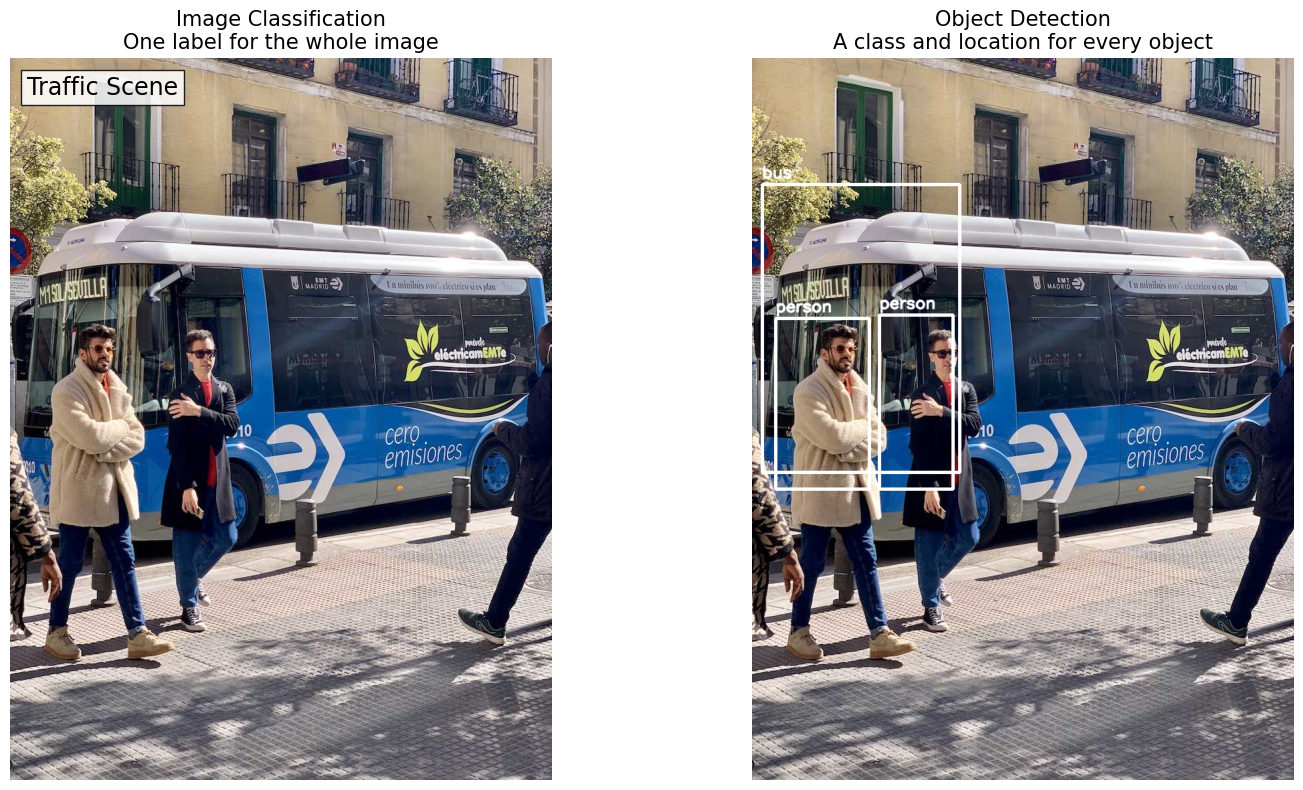

In [4]:
# مقارنة بصرية بين Classification وObject Detection
image_path = str(ASSETS / "bus.jpg")
image_bgr = cv2.imread(image_path)

if image_bgr is None:
    raise FileNotFoundError(f"تعذر فتح الصورة: {image_path}")

image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Classification: فئة واحدة للصورة كلها
axes[0].imshow(image_rgb)
axes[0].set_title(
    "Image Classification\nOne label for the whole image",
    fontsize=15
)
axes[0].text(
    25,
    55,
    "Traffic Scene",
    fontsize=17,
    bbox={"facecolor": "white", "alpha": 0.85}
)
axes[0].axis("off")

# Detection: عدة أجسام ومواقع مختلفة
concept_image = image_rgb.copy()
concept_boxes = [
    (15, 190, 310, 620, "bus"),
    (35, 390, 175, 645, "person"),
    (190, 385, 300, 645, "person"),
]

for x1, y1, x2, y2, label in concept_boxes:
    cv2.rectangle(
        concept_image,
        (x1, y1),
        (x2, y2),
        (255, 255, 255),
        4
    )
    cv2.putText(
        concept_image,
        label,
        (x1, max(y1 - 10, 25)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (255, 255, 255),
        2,
        cv2.LINE_AA
    )

axes[1].imshow(concept_image)
axes[1].set_title(
    "Object Detection\nA class and location for every object",
    fontsize=15
)
axes[1].axis("off")

plt.tight_layout()
plt.show()

<style>
.rtl-cell {
    direction: rtl !important;
    text-align: right !important;
    line-height: 1.9 !important;
    font-size: 17px !important;
    font-family: Arial, Tahoma, sans-serif !important;
}
.rtl-cell p,
.rtl-cell h1,
.rtl-cell h2,
.rtl-cell h3,
.rtl-cell h4,
.rtl-cell h5,
.rtl-cell h6,
.rtl-cell li,
.rtl-cell blockquote,
.rtl-cell th,
.rtl-cell td {
    direction: rtl !important;
    text-align: right !important;
}
.rtl-cell ul,
.rtl-cell ol {
    direction: rtl !important;
    text-align: right !important;
    padding-right: 2em !important;
    padding-left: 0 !important;
}
.rtl-cell blockquote {
    border-right: 4px solid #d0d7de !important;
    border-left: none !important;
    margin-right: 0 !important;
    padding-right: 1em !important;
}
.rtl-cell table {
    direction: rtl !important;
    text-align: right !important;
    margin-right: 0 !important;
    margin-left: auto !important;
    border-collapse: collapse !important;
}
.rtl-cell th,
.rtl-cell td {
    padding: 7px 10px !important;
}
.rtl-cell code {
    direction: ltr !important;
    unicode-bidi: isolate !important;
}
.rtl-cell pre,
.rtl-cell pre code {
    direction: ltr !important;
    text-align: left !important;
    unicode-bidi: embed !important;
}
.rtl-cell .ltr,
.rtl-cell [dir="ltr"] {
    direction: ltr !important;
    text-align: left !important;
}
</style>

<div class="rtl-cell" dir="rtl" style="direction:rtl !important; text-align:right !important;">
<h2>🤔 فكر قبل المتابعة</h2>
<ol>
<li>هل أعطى نموذج Classification موقع الحافلة؟</li>
<li>هل يستطيع Classification معرفة عدد الأشخاص؟</li>
<li>ما المعلومات الإضافية التي وفرها Object Detection؟</li>
<li>لماذا نحتاج Object Detection في نظام المرور الذكي؟</li>
</ol>
</div>

<style>
.rtl-cell {
    direction: rtl !important;
    text-align: right !important;
    line-height: 1.9 !important;
    font-size: 17px !important;
    font-family: Arial, Tahoma, sans-serif !important;
}
.rtl-cell p,
.rtl-cell h1,
.rtl-cell h2,
.rtl-cell h3,
.rtl-cell h4,
.rtl-cell h5,
.rtl-cell h6,
.rtl-cell li,
.rtl-cell blockquote,
.rtl-cell th,
.rtl-cell td {
    direction: rtl !important;
    text-align: right !important;
}
.rtl-cell ul,
.rtl-cell ol {
    direction: rtl !important;
    text-align: right !important;
    padding-right: 2em !important;
    padding-left: 0 !important;
}
.rtl-cell blockquote {
    border-right: 4px solid #d0d7de !important;
    border-left: none !important;
    margin-right: 0 !important;
    padding-right: 1em !important;
}
.rtl-cell table {
    direction: rtl !important;
    text-align: right !important;
    margin-right: 0 !important;
    margin-left: auto !important;
    border-collapse: collapse !important;
}
.rtl-cell th,
.rtl-cell td {
    padding: 7px 10px !important;
}
.rtl-cell code {
    direction: ltr !important;
    unicode-bidi: isolate !important;
}
.rtl-cell pre,
.rtl-cell pre code {
    direction: ltr !important;
    text-align: left !important;
    unicode-bidi: embed !important;
}
.rtl-cell .ltr,
.rtl-cell [dir="ltr"] {
    direction: ltr !important;
    text-align: left !important;
}
</style>

<div class="rtl-cell" dir="rtl" style="direction:rtl !important; text-align:right !important;">
<hr />
<h1>2. ماذا يُخرج نموذج كشف الأجسام؟</h1>
<p>لكل جسم مكتشف يعطينا النموذج ثلاثة عناصر أساسية:</p>
<h3>1) Bounding Box</h3>
<p>مستطيل يحدد مكان الجسم في الصورة.</p>
<ul>
<li><code>(x1, y1)</code>: الزاوية العلوية اليسرى</li>
<li><code>(x2, y2)</code>: الزاوية السفلية اليمنى</li>
</ul>
<h3>2) Class</h3>
<p>اسم الفئة المتوقعة، مثل:</p>
<ul>
<li><code>person</code></li>
<li><code>car</code></li>
<li><code>bus</code></li>
<li><code>truck</code></li>
</ul>
<h3>3) Confidence Score</h3>
<p>رقم بين <code>0</code> و<code>1</code> يعبّر عن ثقة النموذج في التوقع.</p>
<p>مثال:</p>
<pre><code class="language-text">car: 0.91
</code></pre>
<p>أي أن النموذج واثق بنسبة تقريبية <code>91%</code> أن الجسم سيارة.</p>
</div>

<div style="text-align:center; margin:24px 0;">
<img
src="https://raw.githubusercontent.com/syriascitech/Medad-CV-Bootcamp/main/Week6/media/detected-object-box-example.png"
alt="Bounding Box Representation"
width="700">
</div>

<style>
.confidence-section {
    direction: rtl !important;
    text-align: right !important;
    line-height: 1.9;
    font-size: 17px;
    font-family: Arial, Tahoma, sans-serif;
}

.confidence-section h2,
.confidence-section h3,
.confidence-section p,
.confidence-section li {
    direction: rtl !important;
    text-align: right !important;
}

.confidence-section ul {
    direction: rtl !important;
    text-align: right !important;
    padding-right: 28px;
    padding-left: 0;
}

.confidence-section code,
.confidence-section .english {
    direction: ltr !important;
    unicode-bidi: isolate;
}

.confidence-note {
    background-color: rgba(127, 127, 127, 0.12);
    border-right: 5px solid #777;
    padding: 12px 18px;
    margin-top: 18px;
    border-radius: 6px;
}
</style>

<div class="confidence-section" dir="rtl">

<h2>⚖️ ملاحظة مهمة عن Confidence Threshold</h2>

<p>
يعطي نموذج
كشف الجسم
لكل جسم مكتشف قيمة تسمى
<span class="english"><b>Confidence Score</b></span>.
وهي قيمة بين
<span class="english">0</span>
و
<span class="english">1</span>
تعبّر عن مدى ثقة النموذج في النتيجة.
</p>

<p>
أما
<span class="english"><b>Confidence Threshold</b></span>
فهي الحد الأدنى الذي نحدده لقبول الكشف.
</p>

<h3>🔽 عند استخدام Confidence منخفضة</h3>

<ul>
    <li>يقبل النموذج نتائج أكثر.</li>
    <li>قد يكتشف أجساماً صغيرة أو بعيدة.</li>
    <li>
        لكنه قد يعرض مربعات خاطئة أكثر، وتسمى
        <span class="english"><b>False Positives</b></span>.
    </li>
</ul>

<h3>🔼 عند استخدام Confidence مرتفعة</h3>

<ul>
    <li>يعرض النموذج النتائج التي يثق بها بدرجة أكبر فقط.</li>
    <li>تقل المربعات والإنذارات الخاطئة.</li>
    <li>
        لكنه قد يفوّت أجساماً حقيقية، وتسمى هذه الحالات
        <span class="english"><b>False Negatives</b></span>.
    </li>
</ul>

<div class="confidence-note">

<b>لا توجد قيمة مثالية لجميع الصور.</b>

تعتمد القيمة المناسبة على عدة عوامل، مثل الإضاءة، وبعد الأجسام، وحجمها،
وجودة الكاميرا، وطبيعة التطبيق.

لذلك سنجرّب عدة قيم على الصورة نفسها، ثم نقارن النتائج عملياً.

</div>

<br>

<div style="text-align:center;">

<img
src="https://raw.githubusercontent.com/syriascitech/Medad-CV-Bootcamp/main/Week6/media/confidence_threshold_comparison.jpg"
alt="Comparison of different YOLO confidence thresholds"
style="max-width:950px; width:100%; border-radius:8px;">

<p style="text-align:center; font-size:14px; margin-top:8px;">
مقارنة تأثير تغيير قيمة Confidence Threshold على عدد الأجسام المكتشفة.
</p>

</div>

</div>

<style>
.yolo-section {
    direction: rtl !important;
    text-align: right !important;
    line-height: 1.9;
    font-size: 17px;
    font-family: Arial, Tahoma, sans-serif;
}

.yolo-section h1,
.yolo-section p {
    direction: rtl !important;
    text-align: right !important;
}

.yolo-section .english {
    direction: ltr !important;
    unicode-bidi: isolate;
}
</style>

<div class="yolo-section" dir="rtl">

<h1>3. ما معنى YOLO؟</h1>

<p style="text-align:center; font-size:21px;">
<span class="english"><b>YOLO = You Only Look Once</b></span>
</p>

<p>
يعالج نموذج <span class="english"><b>YOLO</b></span>
الصورة كاملة خلال تمرير واحد، ثم يحدد الأجسام ومواقعها وفئاتها.
</p>

<div style="text-align:center; margin-top:20px;">

<img
src="https://raw.githubusercontent.com/syriascitech/Medad-CV-Bootcamp/main/Week6/media/yolo_meaning_explainer.gif"
alt="YOLO explanation animation"
style="width:100%; max-width:1000px; border-radius:10px;">

</div>

<p style="text-align:center; margin-top:15px;">
لهذا يعد YOLO مناسباً للتطبيقات اللحظية مثل كاميرات المرور والقيادة الذاتية.
</p>

</div>

<style>
.rtl-cell {
    direction: rtl !important;
    text-align: right !important;
    line-height: 1.9 !important;
    font-size: 17px !important;
    font-family: Arial, Tahoma, sans-serif !important;
}
.rtl-cell p,
.rtl-cell h1,
.rtl-cell h2,
.rtl-cell h3,
.rtl-cell h4,
.rtl-cell h5,
.rtl-cell h6,
.rtl-cell li,
.rtl-cell blockquote,
.rtl-cell th,
.rtl-cell td {
    direction: rtl !important;
    text-align: right !important;
}
.rtl-cell ul,
.rtl-cell ol {
    direction: rtl !important;
    text-align: right !important;
    padding-right: 2em !important;
    padding-left: 0 !important;
}
.rtl-cell blockquote {
    border-right: 4px solid #d0d7de !important;
    border-left: none !important;
    margin-right: 0 !important;
    padding-right: 1em !important;
}
.rtl-cell table {
    direction: rtl !important;
    text-align: right !important;
    margin-right: 0 !important;
    margin-left: auto !important;
    border-collapse: collapse !important;
}
.rtl-cell th,
.rtl-cell td {
    padding: 7px 10px !important;
}
.rtl-cell code {
    direction: ltr !important;
    unicode-bidi: isolate !important;
}
.rtl-cell pre,
.rtl-cell pre code {
    direction: ltr !important;
    text-align: left !important;
    unicode-bidi: embed !important;
}
.rtl-cell .ltr,
.rtl-cell [dir="ltr"] {
    direction: ltr !important;
    text-align: left !important;
}
</style>

<div class="rtl-cell" dir="rtl" style="direction:rtl !important; text-align:right !important;">
<hr />
<h1>4. بنية YOLO بالمستوى العام</h1>

<h2>4.1 Backbone</h2>
<p>يستخرج الميزات البصرية من الصورة:</p>
<ul>
<li>الحواف والأنسجة في الطبقات الأولى</li>
<li>أجزاء الأجسام في الطبقات الوسطى</li>
<li>ميزات أكثر دلالة في الطبقات العميقة</li>
</ul>
<h2>4.2 Neck</h2>
<p>يدمج ميزات قادمة من مستويات مختلفة.</p>
<p>السبب: الأجسام في الطريق ليست بالحجم نفسه:</p>
<ul>
<li>المشاة البعيدون قد يظهرون بأحجام صغيرة</li>
<li>السيارات القريبة تظهر بأحجام كبيرة</li>
<li>الشاحنات والحافلات تحتاج مجال رؤية أكبر</li>
</ul>
<h2>4.3 Detection Head</h2>
<p>يحوّل خرائط الميزات إلى توقعات نهائية:</p>
<ul>
<li>مكان الجسم</li>
<li>حجم المربع</li>
<li>فئة الجسم</li>
<li>درجة الثقة</li>
</ul>
<div style="text-align:center;">

<img
src="https://raw.githubusercontent.com/syriascitech/Medad-CV-Bootcamp/main/Week6/media/yolo_architecture_diagram.png"
alt="Comparison of different YOLO confidence thresholds"
style="max-width:950px; width:100%; border-radius:8px;">


</div>
</div>

<style>
.rtl-cell {
    direction: rtl !important;
    text-align: right !important;
    line-height: 1.9 !important;
    font-size: 17px !important;
    font-family: Arial, Tahoma, sans-serif !important;
}
.rtl-cell p,
.rtl-cell h1,
.rtl-cell h2,
.rtl-cell h3,
.rtl-cell h4,
.rtl-cell h5,
.rtl-cell h6,
.rtl-cell li,
.rtl-cell blockquote,
.rtl-cell th,
.rtl-cell td {
    direction: rtl !important;
    text-align: right !important;
}
.rtl-cell ul,
.rtl-cell ol {
    direction: rtl !important;
    text-align: right !important;
    padding-right: 2em !important;
    padding-left: 0 !important;
}
.rtl-cell blockquote {
    border-right: 4px solid #d0d7de !important;
    border-left: none !important;
    margin-right: 0 !important;
    padding-right: 1em !important;
}
.rtl-cell table {
    direction: rtl !important;
    text-align: right !important;
    margin-right: 0 !important;
    margin-left: auto !important;
    border-collapse: collapse !important;
}
.rtl-cell th,
.rtl-cell td {
    padding: 7px 10px !important;
}
.rtl-cell code {
    direction: ltr !important;
    unicode-bidi: isolate !important;
}
.rtl-cell pre,
.rtl-cell pre code {
    direction: ltr !important;
    text-align: left !important;
    unicode-bidi: embed !important;
}
.rtl-cell .ltr,
.rtl-cell [dir="ltr"] {
    direction: ltr !important;
    text-align: left !important;
}
</style>

<div class="rtl-cell" dir="rtl" style="direction:rtl !important; text-align:right !important;">
<h2>الكشف متعدد المقاييس Multi-scale Detection</h2>
<p>YOLO لا يعتمد على خريطة ميزات واحدة فقط.</p>
<p>بشكل مبسط، يستخدم مستويات مختلفة للكشف عن:</p>
<table>
<thead>
<tr>
  <th>مستوى الميزات</th>
  <th>يفيد غالباً في</th>
</tr>
</thead>
<tbody>
<tr>
  <td>دقة مكانية أعلى</td>
  <td>الأجسام الصغيرة والبعيدة</td>
</tr>
<tr>
  <td>مستوى متوسط</td>
  <td>الأجسام متوسطة الحجم</td>
</tr>
<tr>
  <td>مجال رؤية أكبر</td>
  <td>الأجسام الكبيرة والقريبة</td>
</tr>
</tbody>
</table>
<blockquote>
<p>هذه الفكرة مهمة جداً في أنظمة المرور، لأن حجم السيارة يتغير كثيراً حسب بعدها عن الكاميرا.</p>
</blockquote>
</div>

<style>
.rtl-cell {
    direction: rtl !important;
    text-align: right !important;
    line-height: 1.9 !important;
    font-size: 17px !important;
    font-family: Arial, Tahoma, sans-serif !important;
}
.rtl-cell p,
.rtl-cell h1,
.rtl-cell h2,
.rtl-cell h3,
.rtl-cell h4,
.rtl-cell h5,
.rtl-cell h6,
.rtl-cell li,
.rtl-cell blockquote,
.rtl-cell th,
.rtl-cell td {
    direction: rtl !important;
    text-align: right !important;
}
.rtl-cell ul,
.rtl-cell ol {
    direction: rtl !important;
    text-align: right !important;
    padding-right: 2em !important;
    padding-left: 0 !important;
}
.rtl-cell blockquote {
    border-right: 4px solid #d0d7de !important;
    border-left: none !important;
    margin-right: 0 !important;
    padding-right: 1em !important;
}
.rtl-cell table {
    direction: rtl !important;
    text-align: right !important;
    margin-right: 0 !important;
    margin-left: auto !important;
    border-collapse: collapse !important;
}
.rtl-cell th,
.rtl-cell td {
    padding: 7px 10px !important;
}
.rtl-cell code {
    direction: ltr !important;
    unicode-bidi: isolate !important;
}
.rtl-cell pre,
.rtl-cell pre code {
    direction: ltr !important;
    text-align: left !important;
    unicode-bidi: embed !important;
}
.rtl-cell .ltr,
.rtl-cell [dir="ltr"] {
    direction: ltr !important;
    text-align: left !important;
}
</style>

<div class="rtl-cell" dir="rtl" style="direction:rtl !important; text-align:right !important;">
<h2>ما هي NMS؟</h2>
<p>قد يتنبأ النموذج بعدة مربعات متداخلة للجسم نفسه.<br />
تقوم <strong>Non-Maximum Suppression – NMS</strong> بإزالة المربعات المكررة تقريباً والإبقاء على المربع الأقوى.</p>
<p>بشكل مبسط:</p>
<ol>
<li>نختار المربع صاحب أعلى Confidence.</li>
<li>نقارن المربعات الأخرى معه.</li>
<li>نحذف المربعات المتداخلة معه بشدة.</li>
<li>نكرر العملية مع بقية المربعات.</li>
</ol>
<p>يُقاس التداخل غالباً باستخدام <strong>IoU – Intersection over Union</strong>:</p>
<p>[
IoU = \frac{Area\ of\ Intersection}{Area\ of\ Union}
]</p>
<p>لن ننفذ NMS يدوياً؛ مكتبة Ultralytics تطبق مرحلة المعالجة المناسبة تلقائياً.</p>
</div>

<div style="text-align:center; margin:24px 0;">
<img
src="https://raw.githubusercontent.com/syriascitech/Medad-CV-Bootcamp/main/Week6/media/nms_explanation.gif"
alt="Non-Maximum Suppression explanation"
width="700">
</div>

<style>
.rtl-cell {
    direction: rtl !important;
    text-align: right !important;
    line-height: 1.9 !important;
    font-size: 17px !important;
    font-family: Arial, Tahoma, sans-serif !important;
}
.rtl-cell p,
.rtl-cell h1,
.rtl-cell h2,
.rtl-cell h3,
.rtl-cell h4,
.rtl-cell h5,
.rtl-cell h6,
.rtl-cell li,
.rtl-cell blockquote,
.rtl-cell th,
.rtl-cell td {
    direction: rtl !important;
    text-align: right !important;
}
.rtl-cell ul,
.rtl-cell ol {
    direction: rtl !important;
    text-align: right !important;
    padding-right: 2em !important;
    padding-left: 0 !important;
}
.rtl-cell blockquote {
    border-right: 4px solid #d0d7de !important;
    border-left: none !important;
    margin-right: 0 !important;
    padding-right: 1em !important;
}
.rtl-cell table {
    direction: rtl !important;
    text-align: right !important;
    margin-right: 0 !important;
    margin-left: auto !important;
    border-collapse: collapse !important;
}
.rtl-cell th,
.rtl-cell td {
    padding: 7px 10px !important;
}
.rtl-cell code {
    direction: ltr !important;
    unicode-bidi: isolate !important;
}
.rtl-cell pre,
.rtl-cell pre code {
    direction: ltr !important;
    text-align: left !important;
    unicode-bidi: embed !important;
}
.rtl-cell .ltr,
.rtl-cell [dir="ltr"] {
    direction: ltr !important;
    text-align: left !important;
}
</style>

<div class="rtl-cell" dir="rtl" style="direction:rtl !important; text-align:right !important;">
<hr />
<h1>5. Pretrained Models</h1>
<p>النموذج الجاهز هو نموذج تم تدريبه مسبقاً على عدد كبير من الصور.</p>
<p>سنستخدم نموذجاً مدرباً على <strong>COCO</strong>، وهي قاعدة بيانات تحتوي على فئات يومية متعددة.</p>
<p>الفئات المهمة لتطبيقنا المروري تشمل:</p>
<table>
<thead>
<tr>
  <th style="text-align:right">Class ID</th>
  <th>Class Name</th>
</tr>
</thead>
<tbody>
<tr>
  <td style="text-align:right">0</td>
  <td>person</td>
</tr>
<tr>
  <td style="text-align:right">1</td>
  <td>bicycle</td>
</tr>
<tr>
  <td style="text-align:right">2</td>
  <td>car</td>
</tr>
<tr>
  <td style="text-align:right">3</td>
  <td>motorcycle</td>
</tr>
<tr>
  <td style="text-align:right">5</td>
  <td>bus</td>
</tr>
<tr>
  <td style="text-align:right">7</td>
  <td>truck</td>
</tr>
</tbody>
</table>
<p>سنستخدم <code>YOLO11n</code>:</p>
<ul>
<li>الحرف <code>n</code> يعني Nano</li>
<li>حجمه صغير ومناسب للتجارب التعليمية</li>
<li>لا نحتاج إلى تدريبه في هذا الأسبوع</li>
<li>سيتم تنزيل الأوزان تلقائياً عند أول تشغيل</li>
</ul>
</div>

<style>
.rtl-cell {
    direction: rtl !important;
    text-align: right !important;
    line-height: 1.9 !important;
    font-size: 17px !important;
    font-family: Arial, Tahoma, sans-serif !important;
}
.rtl-cell p,
.rtl-cell h1,
.rtl-cell h2,
.rtl-cell h3,
.rtl-cell h4,
.rtl-cell h5,
.rtl-cell h6,
.rtl-cell li,
.rtl-cell blockquote,
.rtl-cell th,
.rtl-cell td {
    direction: rtl !important;
    text-align: right !important;
}
.rtl-cell ul,
.rtl-cell ol {
    direction: rtl !important;
    text-align: right !important;
    padding-right: 2em !important;
    padding-left: 0 !important;
}
.rtl-cell blockquote {
    border-right: 4px solid #d0d7de !important;
    border-left: none !important;
    margin-right: 0 !important;
    padding-right: 1em !important;
}
.rtl-cell table {
    direction: rtl !important;
    text-align: right !important;
    margin-right: 0 !important;
    margin-left: auto !important;
    border-collapse: collapse !important;
}
.rtl-cell th,
.rtl-cell td {
    padding: 7px 10px !important;
}
.rtl-cell code {
    direction: ltr !important;
    unicode-bidi: isolate !important;
}
.rtl-cell pre,
.rtl-cell pre code {
    direction: ltr !important;
    text-align: left !important;
    unicode-bidi: embed !important;
}
.rtl-cell .ltr,
.rtl-cell [dir="ltr"] {
    direction: ltr !important;
    text-align: left !important;
}
</style>

<div class="rtl-cell" dir="rtl" style="direction:rtl !important; text-align:right !important;">
<hr />
<h1>6. تحميل نموذج YOLO جاهز</h1>
<p>عند تنفيذ السطر التالي لأول مرة، تقوم المكتبة بتنزيل ملف الأوزان تلقائياً.</p>
</div>

In [5]:
MODEL_NAME = "yolo11n.pt"

model = YOLO(MODEL_NAME)
print("✅ تم تحميل النموذج:", MODEL_NAME)

✅ تم تحميل النموذج: yolo11n.pt


<style>
.rtl-cell {
    direction: rtl !important;
    text-align: right !important;
    line-height: 1.9 !important;
    font-size: 17px !important;
    font-family: Arial, Tahoma, sans-serif !important;
}
.rtl-cell p,
.rtl-cell h1,
.rtl-cell h2,
.rtl-cell h3,
.rtl-cell h4,
.rtl-cell h5,
.rtl-cell h6,
.rtl-cell li,
.rtl-cell blockquote,
.rtl-cell th,
.rtl-cell td {
    direction: rtl !important;
    text-align: right !important;
}
.rtl-cell ul,
.rtl-cell ol {
    direction: rtl !important;
    text-align: right !important;
    padding-right: 2em !important;
    padding-left: 0 !important;
}
.rtl-cell blockquote {
    border-right: 4px solid #d0d7de !important;
    border-left: none !important;
    margin-right: 0 !important;
    padding-right: 1em !important;
}
.rtl-cell table {
    direction: rtl !important;
    text-align: right !important;
    margin-right: 0 !important;
    margin-left: auto !important;
    border-collapse: collapse !important;
}
.rtl-cell th,
.rtl-cell td {
    padding: 7px 10px !important;
}
.rtl-cell code {
    direction: ltr !important;
    unicode-bidi: isolate !important;
}
.rtl-cell pre,
.rtl-cell pre code {
    direction: ltr !important;
    text-align: left !important;
    unicode-bidi: embed !important;
}
.rtl-cell .ltr,
.rtl-cell [dir="ltr"] {
    direction: ltr !important;
    text-align: left !important;
}
</style>

<div class="rtl-cell" dir="rtl" style="direction:rtl !important; text-align:right !important;">
<h2>عرض معلومات مختصرة عن النموذج</h2>
<p>لا نحتاج إلى حفظ تفاصيل كل طبقة.<br />
المطلوب هو ملاحظة أن النموذج يحتوي على عدد كبير من الطبقات والبارامترات التي تعلمت استخراج الميزات وإنتاج الكشف.</p>
</div>

In [6]:
model.info()

YOLO11n summary: 181 layers, 2,624,080 parameters, 0 gradients, 6.7 GFLOPs


(181, 2624080, 0, 6.6733184)

<style>
.rtl-cell {
    direction: rtl !important;
    text-align: right !important;
    line-height: 1.9 !important;
    font-size: 17px !important;
    font-family: Arial, Tahoma, sans-serif !important;
}
.rtl-cell p,
.rtl-cell h1,
.rtl-cell h2,
.rtl-cell h3,
.rtl-cell h4,
.rtl-cell h5,
.rtl-cell h6,
.rtl-cell li,
.rtl-cell blockquote,
.rtl-cell th,
.rtl-cell td {
    direction: rtl !important;
    text-align: right !important;
}
.rtl-cell ul,
.rtl-cell ol {
    direction: rtl !important;
    text-align: right !important;
    padding-right: 2em !important;
    padding-left: 0 !important;
}
.rtl-cell blockquote {
    border-right: 4px solid #d0d7de !important;
    border-left: none !important;
    margin-right: 0 !important;
    padding-right: 1em !important;
}
.rtl-cell table {
    direction: rtl !important;
    text-align: right !important;
    margin-right: 0 !important;
    margin-left: auto !important;
    border-collapse: collapse !important;
}
.rtl-cell th,
.rtl-cell td {
    padding: 7px 10px !important;
}
.rtl-cell code {
    direction: ltr !important;
    unicode-bidi: isolate !important;
}
.rtl-cell pre,
.rtl-cell pre code {
    direction: ltr !important;
    text-align: left !important;
    unicode-bidi: embed !important;
}
.rtl-cell .ltr,
.rtl-cell [dir="ltr"] {
    direction: ltr !important;
    text-align: left !important;
}
</style>

<div class="rtl-cell" dir="rtl" style="direction:rtl !important; text-align:right !important;">
<h2>اسماء الفئات التي يعرفها النموذج</h2>
</div>

In [9]:
print("عدد الفئات:", len(model.names))

for class_id in range(80):
    print(f"{class_id:2d} -> {model.names[class_id]}")

عدد الفئات: 80
 0 -> person
 1 -> bicycle
 2 -> car
 3 -> motorcycle
 4 -> airplane
 5 -> bus
 6 -> train
 7 -> truck
 8 -> boat
 9 -> traffic light
10 -> fire hydrant
11 -> stop sign
12 -> parking meter
13 -> bench
14 -> bird
15 -> cat
16 -> dog
17 -> horse
18 -> sheep
19 -> cow
20 -> elephant
21 -> bear
22 -> zebra
23 -> giraffe
24 -> backpack
25 -> umbrella
26 -> handbag
27 -> tie
28 -> suitcase
29 -> frisbee
30 -> skis
31 -> snowboard
32 -> sports ball
33 -> kite
34 -> baseball bat
35 -> baseball glove
36 -> skateboard
37 -> surfboard
38 -> tennis racket
39 -> bottle
40 -> wine glass
41 -> cup
42 -> fork
43 -> knife
44 -> spoon
45 -> bowl
46 -> banana
47 -> apple
48 -> sandwich
49 -> orange
50 -> broccoli
51 -> carrot
52 -> hot dog
53 -> pizza
54 -> donut
55 -> cake
56 -> chair
57 -> couch
58 -> potted plant
59 -> bed
60 -> dining table
61 -> toilet
62 -> tv
63 -> laptop
64 -> mouse
65 -> remote
66 -> keyboard
67 -> cell phone
68 -> microwave
69 -> oven
70 -> toaster
71 -> sink
72 

<style>
.rtl-cell {
    direction: rtl !important;
    text-align: right !important;
    line-height: 1.9 !important;
    font-size: 17px !important;
    font-family: Arial, Tahoma, sans-serif !important;
}
.rtl-cell p,
.rtl-cell h1,
.rtl-cell h2,
.rtl-cell h3,
.rtl-cell h4,
.rtl-cell h5,
.rtl-cell h6,
.rtl-cell li,
.rtl-cell blockquote,
.rtl-cell th,
.rtl-cell td {
    direction: rtl !important;
    text-align: right !important;
}
.rtl-cell ul,
.rtl-cell ol {
    direction: rtl !important;
    text-align: right !important;
    padding-right: 2em !important;
    padding-left: 0 !important;
}
.rtl-cell blockquote {
    border-right: 4px solid #d0d7de !important;
    border-left: none !important;
    margin-right: 0 !important;
    padding-right: 1em !important;
}
.rtl-cell table {
    direction: rtl !important;
    text-align: right !important;
    margin-right: 0 !important;
    margin-left: auto !important;
    border-collapse: collapse !important;
}
.rtl-cell th,
.rtl-cell td {
    padding: 7px 10px !important;
}
.rtl-cell code {
    direction: ltr !important;
    unicode-bidi: isolate !important;
}
.rtl-cell pre,
.rtl-cell pre code {
    direction: ltr !important;
    text-align: left !important;
    unicode-bidi: embed !important;
}
.rtl-cell .ltr,
.rtl-cell [dir="ltr"] {
    direction: ltr !important;
    text-align: left !important;
}
</style>

<div class="rtl-cell" dir="rtl" style="direction:rtl !important; text-align:right !important;">
<hr />
<h1>7. أول عملية كشف على صورة</h1>
<p>سنستخدم صورة تجريبية تأتي مع مكتبة Ultralytics.</p>
</div>

مسار الصورة: /usr/local/lib/python3.13/dist-packages/ultralytics/assets/bus.jpg


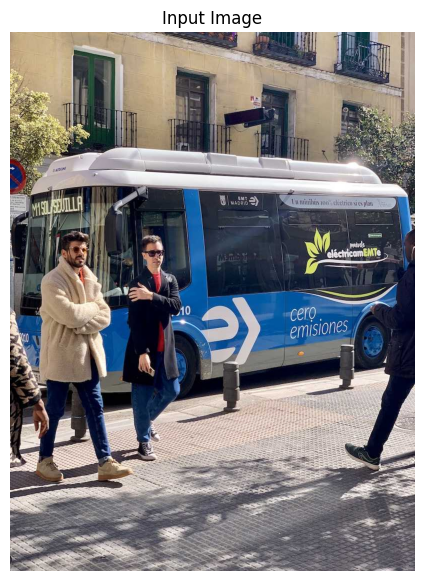

In [13]:
image_path = str(ASSETS / "bus.jpg")
print("مسار الصورة:", image_path)

image_bgr = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 7))
plt.imshow(image_rgb)
plt.axis("off")
plt.title("Input Image")
plt.show()

<style>
.rtl-cell {
    direction: rtl !important;
    text-align: right !important;
    line-height: 1.9 !important;
    font-size: 17px !important;
    font-family: Arial, Tahoma, sans-serif !important;
}
.rtl-cell p,
.rtl-cell h1,
.rtl-cell h2,
.rtl-cell h3,
.rtl-cell h4,
.rtl-cell h5,
.rtl-cell h6,
.rtl-cell li,
.rtl-cell blockquote,
.rtl-cell th,
.rtl-cell td {
    direction: rtl !important;
    text-align: right !important;
}
.rtl-cell ul,
.rtl-cell ol {
    direction: rtl !important;
    text-align: right !important;
    padding-right: 2em !important;
    padding-left: 0 !important;
}
.rtl-cell blockquote {
    border-right: 4px solid #d0d7de !important;
    border-left: none !important;
    margin-right: 0 !important;
    padding-right: 1em !important;
}
.rtl-cell table {
    direction: rtl !important;
    text-align: right !important;
    margin-right: 0 !important;
    margin-left: auto !important;
    border-collapse: collapse !important;
}
.rtl-cell th,
.rtl-cell td {
    padding: 7px 10px !important;
}
.rtl-cell code {
    direction: ltr !important;
    unicode-bidi: isolate !important;
}
.rtl-cell pre,
.rtl-cell pre code {
    direction: ltr !important;
    text-align: left !important;
    unicode-bidi: embed !important;
}
.rtl-cell .ltr,
.rtl-cell [dir="ltr"] {
    direction: ltr !important;
    text-align: left !important;
}
</style>

<div class="rtl-cell" dir="rtl" style="direction:rtl !important; text-align:right !important;">
<h2>تشغيل النموذج</h2>
<p>أهم الإعدادات:</p>
<ul>
<li><code>conf</code>: أقل ثقة نقبل بها</li>
<li><code>iou</code>: مقدار التداخل المستخدم عند معالجة المربعات المتكررة</li>
<li><code>verbose=False</code>: إخفاء الطباعة الطويلة</li>
</ul>
</div>

In [27]:
results = model.predict(
    source=image_path,
    conf=0.50,
    iou=0.50,
    device=DEVICE,
    verbose=False
)

result = results[0]
print("عدد الأجسام المكتشفة:", len(result.boxes))

عدد الأجسام المكتشفة: 5


<style>
.rtl-cell {
    direction: rtl !important;
    text-align: right !important;
    line-height: 1.9 !important;
    font-size: 17px !important;
    font-family: Arial, Tahoma, sans-serif !important;
}
.rtl-cell p,
.rtl-cell h1,
.rtl-cell h2,
.rtl-cell h3,
.rtl-cell h4,
.rtl-cell h5,
.rtl-cell h6,
.rtl-cell li,
.rtl-cell blockquote,
.rtl-cell th,
.rtl-cell td {
    direction: rtl !important;
    text-align: right !important;
}
.rtl-cell ul,
.rtl-cell ol {
    direction: rtl !important;
    text-align: right !important;
    padding-right: 2em !important;
    padding-left: 0 !important;
}
.rtl-cell blockquote {
    border-right: 4px solid #d0d7de !important;
    border-left: none !important;
    margin-right: 0 !important;
    padding-right: 1em !important;
}
.rtl-cell table {
    direction: rtl !important;
    text-align: right !important;
    margin-right: 0 !important;
    margin-left: auto !important;
    border-collapse: collapse !important;
}
.rtl-cell th,
.rtl-cell td {
    padding: 7px 10px !important;
}
.rtl-cell code {
    direction: ltr !important;
    unicode-bidi: isolate !important;
}
.rtl-cell pre,
.rtl-cell pre code {
    direction: ltr !important;
    text-align: left !important;
    unicode-bidi: embed !important;
}
.rtl-cell .ltr,
.rtl-cell [dir="ltr"] {
    direction: ltr !important;
    text-align: left !important;
}
</style>

<div class="rtl-cell" dir="rtl" style="direction:rtl !important; text-align:right !important;">
<h2>عرض الصورة بعد الكشف</h2>
</div>

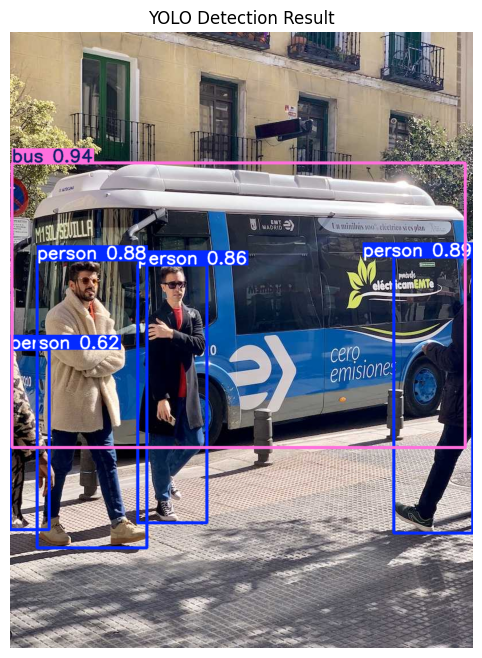

In [28]:
annotated_bgr = result.plot()
annotated_rgb = cv2.cvtColor(annotated_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))
plt.imshow(annotated_rgb)
plt.axis("off")
plt.title("YOLO Detection Result")
plt.show()

<style>
.rtl-cell {
    direction: rtl !important;
    text-align: right !important;
    line-height: 1.9 !important;
    font-size: 17px !important;
    font-family: Arial, Tahoma, sans-serif !important;
}
.rtl-cell p,
.rtl-cell h1,
.rtl-cell h2,
.rtl-cell h3,
.rtl-cell h4,
.rtl-cell h5,
.rtl-cell h6,
.rtl-cell li,
.rtl-cell blockquote,
.rtl-cell th,
.rtl-cell td {
    direction: rtl !important;
    text-align: right !important;
}
.rtl-cell ul,
.rtl-cell ol {
    direction: rtl !important;
    text-align: right !important;
    padding-right: 2em !important;
    padding-left: 0 !important;
}
.rtl-cell blockquote {
    border-right: 4px solid #d0d7de !important;
    border-left: none !important;
    margin-right: 0 !important;
    padding-right: 1em !important;
}
.rtl-cell table {
    direction: rtl !important;
    text-align: right !important;
    margin-right: 0 !important;
    margin-left: auto !important;
    border-collapse: collapse !important;
}
.rtl-cell th,
.rtl-cell td {
    padding: 7px 10px !important;
}
.rtl-cell code {
    direction: ltr !important;
    unicode-bidi: isolate !important;
}
.rtl-cell pre,
.rtl-cell pre code {
    direction: ltr !important;
    text-align: left !important;
    unicode-bidi: embed !important;
}
.rtl-cell .ltr,
.rtl-cell [dir="ltr"] {
    direction: ltr !important;
    text-align: left !important;
}
</style>

<div class="rtl-cell" dir="rtl" style="direction:rtl !important; text-align:right !important;">
<hr />
<h1>8. قراءة النتائج برمجياً</h1>
<p>الرسم وحده غير كافٍ لبناء نظام مرور ذكي.</p>
<p>نحتاج الوصول إلى:</p>
<ul>
<li>إحداثيات كل مربع</li>
<li>فئة الجسم</li>
<li>درجة الثقة</li>
</ul>
<p>الكائن <code>result.boxes</code> يحتوي على هذه المعلومات.</p>
</div>

In [29]:
boxes = result.boxes

print("xyxy shape:", boxes.xyxy.shape)
print("confidence shape:", boxes.conf.shape)
print("class shape:", boxes.cls.shape)

xyxy shape: torch.Size([5, 4])
confidence shape: torch.Size([5])
class shape: torch.Size([5])


<style>
.rtl-cell {
    direction: rtl !important;
    text-align: right !important;
    line-height: 1.9 !important;
    font-size: 17px !important;
    font-family: Arial, Tahoma, sans-serif !important;
}
.rtl-cell p,
.rtl-cell h1,
.rtl-cell h2,
.rtl-cell h3,
.rtl-cell h4,
.rtl-cell h5,
.rtl-cell h6,
.rtl-cell li,
.rtl-cell blockquote,
.rtl-cell th,
.rtl-cell td {
    direction: rtl !important;
    text-align: right !important;
}
.rtl-cell ul,
.rtl-cell ol {
    direction: rtl !important;
    text-align: right !important;
    padding-right: 2em !important;
    padding-left: 0 !important;
}
.rtl-cell blockquote {
    border-right: 4px solid #d0d7de !important;
    border-left: none !important;
    margin-right: 0 !important;
    padding-right: 1em !important;
}
.rtl-cell table {
    direction: rtl !important;
    text-align: right !important;
    margin-right: 0 !important;
    margin-left: auto !important;
    border-collapse: collapse !important;
}
.rtl-cell th,
.rtl-cell td {
    padding: 7px 10px !important;
}
.rtl-cell code {
    direction: ltr !important;
    unicode-bidi: isolate !important;
}
.rtl-cell pre,
.rtl-cell pre code {
    direction: ltr !important;
    text-align: left !important;
    unicode-bidi: embed !important;
}
.rtl-cell .ltr,
.rtl-cell [dir="ltr"] {
    direction: ltr !important;
    text-align: left !important;
}
</style>

<div class="rtl-cell" dir="rtl" style="direction:rtl !important; text-align:right !important;">
<h2>تحويل النتائج إلى جدول</h2>
</div>

In [30]:
rows = []

for box in boxes:
    x1, y1, x2, y2 = box.xyxy[0].cpu().tolist()
    confidence = float(box.conf[0].cpu())
    class_id = int(box.cls[0].cpu())
    class_name = model.names[class_id]

    rows.append({
        "class_id": class_id,
        "class_name": class_name,
        "confidence": round(confidence, 3),
        "x1": round(x1, 1),
        "y1": round(y1, 1),
        "x2": round(x2, 1),
        "y2": round(y2, 1),
        "width": round(x2 - x1, 1),
        "height": round(y2 - y1, 1),
    })

detections_df = pd.DataFrame(rows)
detections_df

,class_id,class_name,confidence,x1,y1,x2,y2,width,height
0,5,bus,0.940,3.8,229.4,796.2,728.4,792.4,499.0
1,0,person,0.888,671.0,394.8,809.8,878.7,138.8,483.9
2,0,person,0.878,47.4,399.6,239.3,904.2,191.9,504.6
3,0,person,0.856,223.1,408.7,344.5,860.4,121.4,451.7
4,0,person,0.622,0.0,556.1,68.9,872.4,68.9,316.3


<style>
.rtl-cell {
    direction: rtl !important;
    text-align: right !important;
    line-height: 1.9 !important;
    font-size: 17px !important;
    font-family: Arial, Tahoma, sans-serif !important;
}
.rtl-cell p,
.rtl-cell h1,
.rtl-cell h2,
.rtl-cell h3,
.rtl-cell h4,
.rtl-cell h5,
.rtl-cell h6,
.rtl-cell li,
.rtl-cell blockquote,
.rtl-cell th,
.rtl-cell td {
    direction: rtl !important;
    text-align: right !important;
}
.rtl-cell ul,
.rtl-cell ol {
    direction: rtl !important;
    text-align: right !important;
    padding-right: 2em !important;
    padding-left: 0 !important;
}
.rtl-cell blockquote {
    border-right: 4px solid #d0d7de !important;
    border-left: none !important;
    margin-right: 0 !important;
    padding-right: 1em !important;
}
.rtl-cell table {
    direction: rtl !important;
    text-align: right !important;
    margin-right: 0 !important;
    margin-left: auto !important;
    border-collapse: collapse !important;
}
.rtl-cell th,
.rtl-cell td {
    padding: 7px 10px !important;
}
.rtl-cell code {
    direction: ltr !important;
    unicode-bidi: isolate !important;
}
.rtl-cell pre,
.rtl-cell pre code {
    direction: ltr !important;
    text-align: left !important;
    unicode-bidi: embed !important;
}
.rtl-cell .ltr,
.rtl-cell [dir="ltr"] {
    direction: ltr !important;
    text-align: left !important;
}
</style>

<div class="rtl-cell" dir="rtl" style="direction:rtl !important; text-align:right !important;">
<h2>ما الذي نستفيده من الإحداثيات؟</h2>
<p>يمكن لاحقاً استخدام الـBounding Boxes في:</p>
<ul>
<li>عد المركبات</li>
<li>معرفة إن كانت المركبة عبرت خطاً افتراضياً</li>
<li>تقدير الازدحام في منطقة معينة</li>
<li>قص صورة السيارة</li>
<li>إرسال المربع إلى خوارزمية Tracking</li>
</ul>
</div>

<style>
.rtl-cell {
    direction: rtl !important;
    text-align: right !important;
    line-height: 1.9 !important;
    font-size: 17px !important;
    font-family: Arial, Tahoma, sans-serif !important;
}
.rtl-cell p,
.rtl-cell h1,
.rtl-cell h2,
.rtl-cell h3,
.rtl-cell h4,
.rtl-cell h5,
.rtl-cell h6,
.rtl-cell li,
.rtl-cell blockquote,
.rtl-cell th,
.rtl-cell td {
    direction: rtl !important;
    text-align: right !important;
}
.rtl-cell ul,
.rtl-cell ol {
    direction: rtl !important;
    text-align: right !important;
    padding-right: 2em !important;
    padding-left: 0 !important;
}
.rtl-cell blockquote {
    border-right: 4px solid #d0d7de !important;
    border-left: none !important;
    margin-right: 0 !important;
    padding-right: 1em !important;
}
.rtl-cell table {
    direction: rtl !important;
    text-align: right !important;
    margin-right: 0 !important;
    margin-left: auto !important;
    border-collapse: collapse !important;
}
.rtl-cell th,
.rtl-cell td {
    padding: 7px 10px !important;
}
.rtl-cell code {
    direction: ltr !important;
    unicode-bidi: isolate !important;
}
.rtl-cell pre,
.rtl-cell pre code {
    direction: ltr !important;
    text-align: left !important;
    unicode-bidi: embed !important;
}
.rtl-cell .ltr,
.rtl-cell [dir="ltr"] {
    direction: ltr !important;
    text-align: left !important;
}
</style>

<div class="rtl-cell" dir="rtl" style="direction:rtl !important; text-align:right !important;">
<hr />
<h1>9. اكتشاف المركبات والمشاة فقط</h1>
<p>لا نريد في مشروع المرور عرض كل فئات COCO.</p>
<p>سنحتفظ بالفئات التالية:</p>
<ul>
<li>person</li>
<li>car</li>
</ul>
<p>سنستخرج أرقام الفئات من <code>model.names</code> بدلاً من الاعتماد على أرقام مكتوبة يدوياً.</p>
</div>

In [32]:
TARGET_NAMES = {
    "person",
    "car",

}

TARGET_CLASS_IDS = [
    class_id
    for class_id, class_name in model.names.items()
    if class_name in TARGET_NAMES
]

print("الفئات المطلوبة:")
for class_id in TARGET_CLASS_IDS:
    print(class_id, "->", model.names[class_id])

الفئات المطلوبة:
0 -> person
2 -> car


<style>
.rtl-cell {
    direction: rtl !important;
    text-align: right !important;
    line-height: 1.9 !important;
    font-size: 17px !important;
    font-family: Arial, Tahoma, sans-serif !important;
}
.rtl-cell p,
.rtl-cell h1,
.rtl-cell h2,
.rtl-cell h3,
.rtl-cell h4,
.rtl-cell h5,
.rtl-cell h6,
.rtl-cell li,
.rtl-cell blockquote,
.rtl-cell th,
.rtl-cell td {
    direction: rtl !important;
    text-align: right !important;
}
.rtl-cell ul,
.rtl-cell ol {
    direction: rtl !important;
    text-align: right !important;
    padding-right: 2em !important;
    padding-left: 0 !important;
}
.rtl-cell blockquote {
    border-right: 4px solid #d0d7de !important;
    border-left: none !important;
    margin-right: 0 !important;
    padding-right: 1em !important;
}
.rtl-cell table {
    direction: rtl !important;
    text-align: right !important;
    margin-right: 0 !important;
    margin-left: auto !important;
    border-collapse: collapse !important;
}
.rtl-cell th,
.rtl-cell td {
    padding: 7px 10px !important;
}
.rtl-cell code {
    direction: ltr !important;
    unicode-bidi: isolate !important;
}
.rtl-cell pre,
.rtl-cell pre code {
    direction: ltr !important;
    text-align: left !important;
    unicode-bidi: embed !important;
}
.rtl-cell .ltr,
.rtl-cell [dir="ltr"] {
    direction: ltr !important;
    text-align: left !important;
}
</style>

<div class="rtl-cell" dir="rtl" style="direction:rtl !important; text-align:right !important;">
<h2>إعادة الكشف مع فلترة الفئات</h2>
</div>

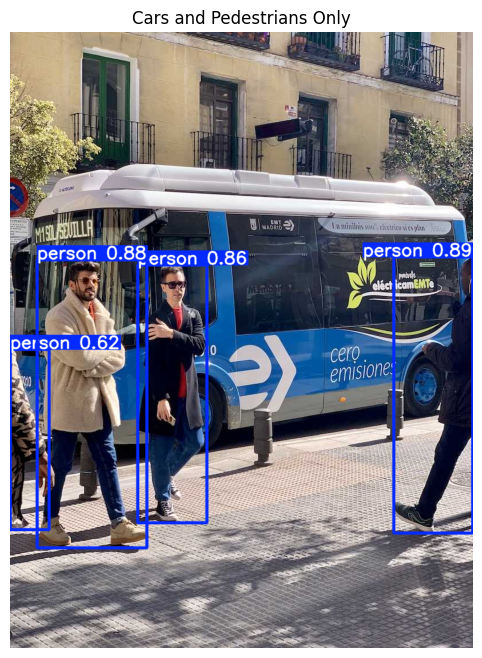

In [33]:
traffic_result = model.predict(
    source=image_path,
    classes=TARGET_CLASS_IDS,
    conf=0.30,
    iou=0.50,
    device=DEVICE,
    verbose=False
)[0]

traffic_annotated_bgr = traffic_result.plot()
traffic_annotated_rgb = cv2.cvtColor(
    traffic_annotated_bgr,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(12, 8))
plt.imshow(traffic_annotated_rgb)
plt.axis("off")
plt.title("Cars and Pedestrians Only")
plt.show()

<style>
.rtl-cell {
    direction: rtl !important;
    text-align: right !important;
    line-height: 1.9 !important;
    font-size: 17px !important;
    font-family: Arial, Tahoma, sans-serif !important;
}
.rtl-cell p,
.rtl-cell h1,
.rtl-cell h2,
.rtl-cell h3,
.rtl-cell h4,
.rtl-cell h5,
.rtl-cell h6,
.rtl-cell li,
.rtl-cell blockquote,
.rtl-cell th,
.rtl-cell td {
    direction: rtl !important;
    text-align: right !important;
}
.rtl-cell ul,
.rtl-cell ol {
    direction: rtl !important;
    text-align: right !important;
    padding-right: 2em !important;
    padding-left: 0 !important;
}
.rtl-cell blockquote {
    border-right: 4px solid #d0d7de !important;
    border-left: none !important;
    margin-right: 0 !important;
    padding-right: 1em !important;
}
.rtl-cell table {
    direction: rtl !important;
    text-align: right !important;
    margin-right: 0 !important;
    margin-left: auto !important;
    border-collapse: collapse !important;
}
.rtl-cell th,
.rtl-cell td {
    padding: 7px 10px !important;
}
.rtl-cell code {
    direction: ltr !important;
    unicode-bidi: isolate !important;
}
.rtl-cell pre,
.rtl-cell pre code {
    direction: ltr !important;
    text-align: left !important;
    unicode-bidi: embed !important;
}
.rtl-cell .ltr,
.rtl-cell [dir="ltr"] {
    direction: ltr !important;
    text-align: left !important;
}
</style>

<div class="rtl-cell" dir="rtl" style="direction:rtl !important; text-align:right !important;">
<h2>عد الأجسام في الإطار الحالي</h2>
<blockquote>
<p>هذا العد يخص صورة أو إطاراً واحداً فقط.<br />
لا يعني أن كل مركبة فريدة عبر الفيديو؛ فقد تُعد السيارة نفسها في عدة إطارات.</p>
</blockquote>
</div>

In [34]:
detected_class_ids = [
    int(class_id)
    for class_id in traffic_result.boxes.cls.cpu().tolist()
]

counts = Counter(model.names[class_id] for class_id in detected_class_ids)

print("العدد داخل الإطار:")
for class_name, count in counts.items():
    print(f"{class_name:12s}: {count}")

print("Total:", sum(counts.values()))

العدد داخل الإطار:
person      : 4
Total: 4


<style>
.rtl-cell {
    direction: rtl !important;
    text-align: right !important;
    line-height: 1.9 !important;
    font-size: 17px !important;
    font-family: Arial, Tahoma, sans-serif !important;
}
.rtl-cell p,
.rtl-cell h1,
.rtl-cell h2,
.rtl-cell h3,
.rtl-cell h4,
.rtl-cell h5,
.rtl-cell h6,
.rtl-cell li,
.rtl-cell blockquote,
.rtl-cell th,
.rtl-cell td {
    direction: rtl !important;
    text-align: right !important;
}
.rtl-cell ul,
.rtl-cell ol {
    direction: rtl !important;
    text-align: right !important;
    padding-right: 2em !important;
    padding-left: 0 !important;
}
.rtl-cell blockquote {
    border-right: 4px solid #d0d7de !important;
    border-left: none !important;
    margin-right: 0 !important;
    padding-right: 1em !important;
}
.rtl-cell table {
    direction: rtl !important;
    text-align: right !important;
    margin-right: 0 !important;
    margin-left: auto !important;
    border-collapse: collapse !important;
}
.rtl-cell th,
.rtl-cell td {
    padding: 7px 10px !important;
}
.rtl-cell code {
    direction: ltr !important;
    unicode-bidi: isolate !important;
}
.rtl-cell pre,
.rtl-cell pre code {
    direction: ltr !important;
    text-align: left !important;
    unicode-bidi: embed !important;
}
.rtl-cell .ltr,
.rtl-cell [dir="ltr"] {
    direction: ltr !important;
    text-align: left !important;
}
</style>

<div class="rtl-cell" dir="rtl" style="direction:rtl !important; text-align:right !important;">
<hr />
<h1>10. تجربة تأثير Confidence Threshold</h1>
<p>سنشغل النموذج على الصورة نفسها باستخدام عدة قيم للثقة.</p>
<p>راقب:</p>
<ul>
<li>عدد المربعات</li>
<li>هل اختفت أجسام صحيحة؟</li>
<li>هل ظهرت توقعات خاطئة؟</li>
</ul>
</div>

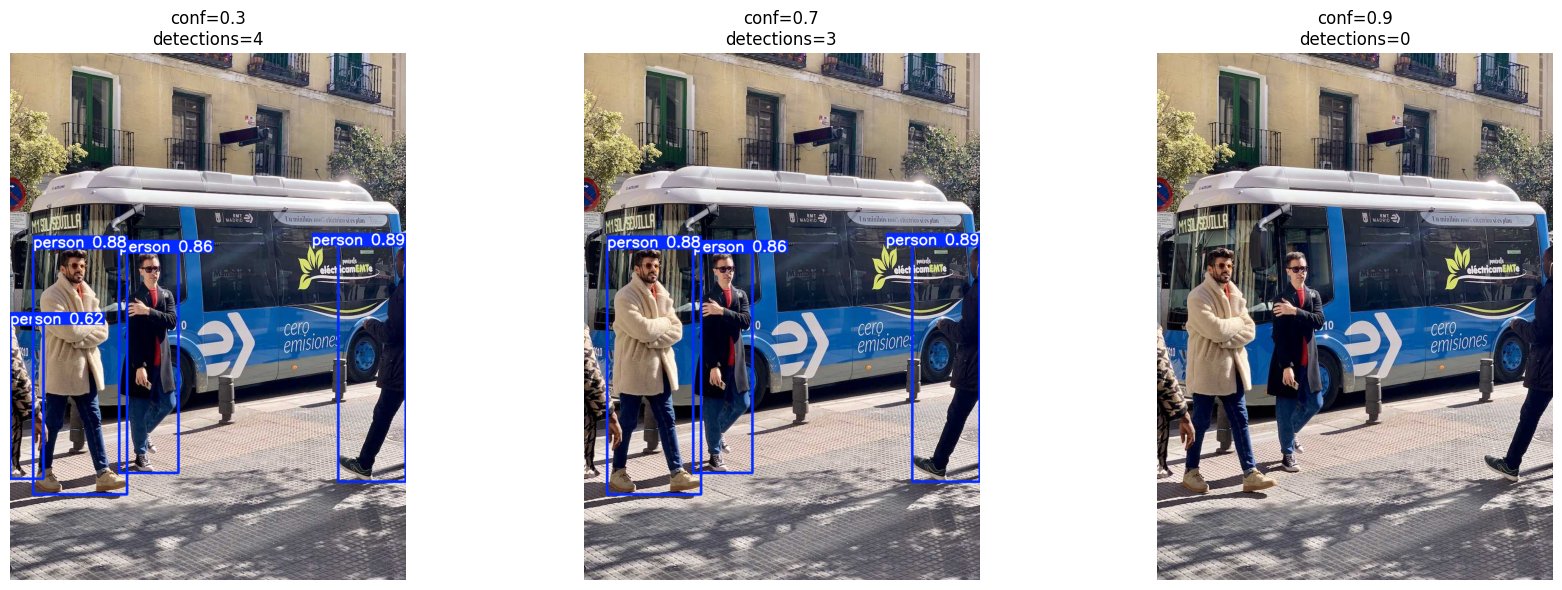

In [35]:
confidence_values = [0.30, 0.70, 0.90]

fig, axes = plt.subplots(
    1,
    len(confidence_values),
    figsize=(18, 6)
)

for ax, confidence_threshold in zip(axes, confidence_values):
    prediction = model.predict(
        source=image_path,
        classes=TARGET_CLASS_IDS,
        conf=confidence_threshold,
        iou=0.50,
        device=DEVICE,
        verbose=False
    )[0]

    plotted_rgb = cv2.cvtColor(
        prediction.plot(),
        cv2.COLOR_BGR2RGB
    )

    ax.imshow(plotted_rgb)
    ax.set_title(
        f"conf={confidence_threshold}\n"
        f"detections={len(prediction.boxes)}"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

<style>
.rtl-cell {
    direction: rtl !important;
    text-align: right !important;
    line-height: 1.9 !important;
    font-size: 17px !important;
    font-family: Arial, Tahoma, sans-serif !important;
}
.rtl-cell p,
.rtl-cell h1,
.rtl-cell h2,
.rtl-cell h3,
.rtl-cell h4,
.rtl-cell h5,
.rtl-cell h6,
.rtl-cell li,
.rtl-cell blockquote,
.rtl-cell th,
.rtl-cell td {
    direction: rtl !important;
    text-align: right !important;
}
.rtl-cell ul,
.rtl-cell ol {
    direction: rtl !important;
    text-align: right !important;
    padding-right: 2em !important;
    padding-left: 0 !important;
}
.rtl-cell blockquote {
    border-right: 4px solid #d0d7de !important;
    border-left: none !important;
    margin-right: 0 !important;
    padding-right: 1em !important;
}
.rtl-cell table {
    direction: rtl !important;
    text-align: right !important;
    margin-right: 0 !important;
    margin-left: auto !important;
    border-collapse: collapse !important;
}
.rtl-cell th,
.rtl-cell td {
    padding: 7px 10px !important;
}
.rtl-cell code {
    direction: ltr !important;
    unicode-bidi: isolate !important;
}
.rtl-cell pre,
.rtl-cell pre code {
    direction: ltr !important;
    text-align: left !important;
    unicode-bidi: embed !important;
}
.rtl-cell .ltr,
.rtl-cell [dir="ltr"] {
    direction: ltr !important;
    text-align: left !important;
}
</style>

<div class="rtl-cell" dir="rtl" style="direction:rtl !important; text-align:right !important;">
<h2>سؤال للنقاش</h2>
<ol>
<li>أي قيمة اكتشفت أجساماً أكثر؟</li>
<li>هل العدد الأكبر يعني دائماً نتيجة أفضل؟</li>
<li>أي قيمة تبدو أكثر مناسبة للصورة؟</li>
<li>هل تتوقع أن القيمة المناسبة تبقى نفسها ليلاً ونهاراً؟</li>
</ol>
</div>

<style>
.rtl-cell {
    direction: rtl !important;
    text-align: right !important;
    line-height: 1.9 !important;
    font-size: 17px !important;
    font-family: Arial, Tahoma, sans-serif !important;
}
.rtl-cell p,
.rtl-cell h1,
.rtl-cell h2,
.rtl-cell h3,
.rtl-cell h4,
.rtl-cell h5,
.rtl-cell h6,
.rtl-cell li,
.rtl-cell blockquote,
.rtl-cell th,
.rtl-cell td {
    direction: rtl !important;
    text-align: right !important;
}
.rtl-cell ul,
.rtl-cell ol {
    direction: rtl !important;
    text-align: right !important;
    padding-right: 2em !important;
    padding-left: 0 !important;
}
.rtl-cell blockquote {
    border-right: 4px solid #d0d7de !important;
    border-left: none !important;
    margin-right: 0 !important;
    padding-right: 1em !important;
}
.rtl-cell table {
    direction: rtl !important;
    text-align: right !important;
    margin-right: 0 !important;
    margin-left: auto !important;
    border-collapse: collapse !important;
}
.rtl-cell th,
.rtl-cell td {
    padding: 7px 10px !important;
}
.rtl-cell code {
    direction: ltr !important;
    unicode-bidi: isolate !important;
}
.rtl-cell pre,
.rtl-cell pre code {
    direction: ltr !important;
    text-align: left !important;
    unicode-bidi: embed !important;
}
.rtl-cell .ltr,
.rtl-cell [dir="ltr"] {
    direction: ltr !important;
    text-align: left !important;
}
</style>

<div class="rtl-cell" dir="rtl" style="direction:rtl !important; text-align:right !important;">
<hr />
<h1>11. تجربة صورة يرفعها الطالب</h1>
<p>شغّل الخلية التالية وارفع صورة شارع أو تقاطع.</p>
<p>يفضّل أن تحتوي الصورة على:</p>
<ul>
<li>سيارات بأحجام مختلفة</li>
<li>أشخاص أو دراجات</li>
<li>أجسام قريبة وأخرى بعيدة</li>
</ul>
</div>

<style>
.rtl-cell {
    direction: rtl !important;
    text-align: right !important;
    line-height: 1.9 !important;
    font-size: 17px !important;
    font-family: Arial, Tahoma, sans-serif !important;
}
.rtl-cell p,
.rtl-cell h1,
.rtl-cell h2,
.rtl-cell h3,
.rtl-cell h4,
.rtl-cell h5,
.rtl-cell h6,
.rtl-cell li,
.rtl-cell blockquote,
.rtl-cell th,
.rtl-cell td {
    direction: rtl !important;
    text-align: right !important;
}
.rtl-cell ul,
.rtl-cell ol {
    direction: rtl !important;
    text-align: right !important;
    padding-right: 2em !important;
    padding-left: 0 !important;
}
.rtl-cell blockquote {
    border-right: 4px solid #d0d7de !important;
    border-left: none !important;
    margin-right: 0 !important;
    padding-right: 1em !important;
}
.rtl-cell table {
    direction: rtl !important;
    text-align: right !important;
    margin-right: 0 !important;
    margin-left: auto !important;
    border-collapse: collapse !important;
}
.rtl-cell th,
.rtl-cell td {
    padding: 7px 10px !important;
}
.rtl-cell code {
    direction: ltr !important;
    unicode-bidi: isolate !important;
}
.rtl-cell pre,
.rtl-cell pre code {
    direction: ltr !important;
    text-align: left !important;
    unicode-bidi: embed !important;
}
.rtl-cell .ltr,
.rtl-cell [dir="ltr"] {
    direction: ltr !important;
    text-align: left !important;
}
</style>

<div class="rtl-cell" dir="rtl" style="direction:rtl !important; text-align:right !important;">
<blockquote>
<p><strong>ملاحظة:</strong> خلية الرفع التالية تعمل مباشرة على Google Colab. عند التشغيل محلياً سيطلب الكود كتابة مسار الملف.</p>
</blockquote>
</div>

In [36]:
try:
    from google.colab import files

    uploaded = files.upload()
    uploaded_image_path = next(iter(uploaded.keys()))

    print("تم رفع:", uploaded_image_path)

except ImportError:
    uploaded_image_path = input(
        "أدخل مسار الصورة على جهازك: "
    )

Saving 1565056d5fb92ea0263a7d3bac87758c.jpg to 1565056d5fb92ea0263a7d3bac87758c.jpg
تم رفع: 1565056d5fb92ea0263a7d3bac87758c.jpg


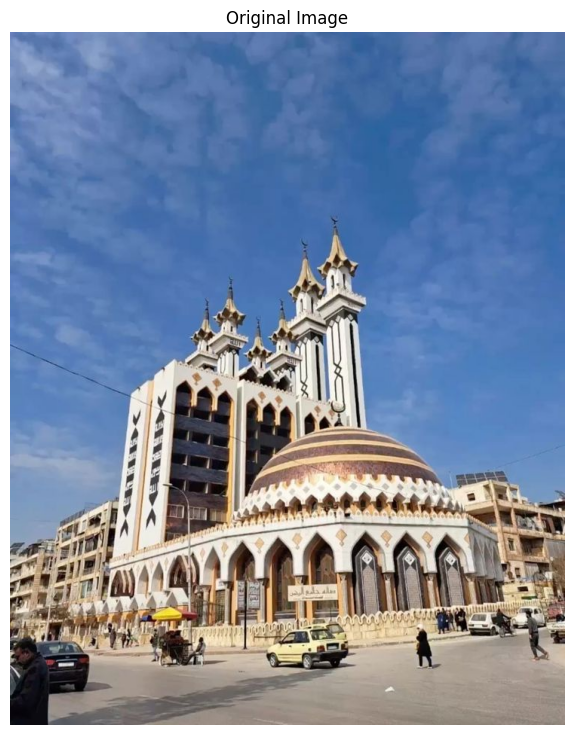

In [41]:
original_rgb = cv2.cvtColor(cv2.imread(uploaded_image_path), cv2.COLOR_BGR2RGB)
plt.figure(figsize=(14, 9))
plt.imshow(original_rgb)
plt.axis("off")
plt.title("Original Image")
plt.show()

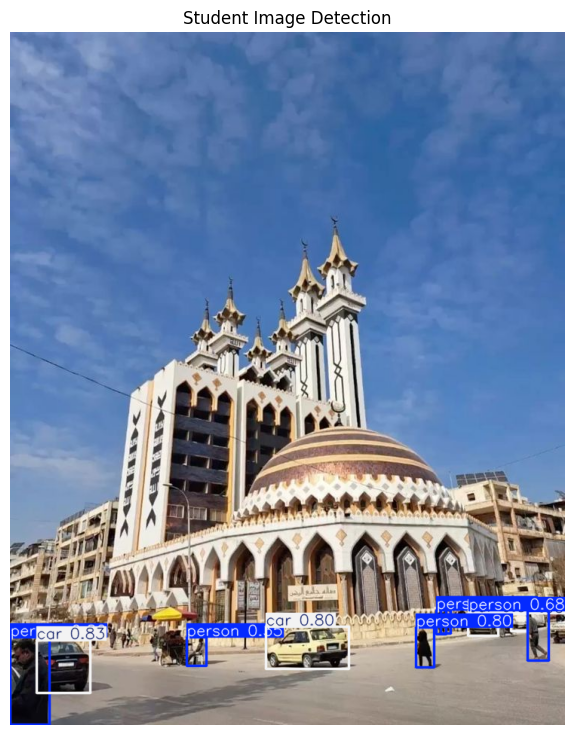

In [42]:
student_result = model.predict(
    source=uploaded_image_path,
    classes=TARGET_CLASS_IDS,
    conf=0.30,
    iou=0.50,
    device=DEVICE,
    verbose=False
)[0]

student_image_rgb = cv2.cvtColor(
    student_result.plot(),
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(14, 9))
plt.imshow(student_image_rgb)
plt.axis("off")
plt.title("Student Image Detection")
plt.show()

<style>
.rtl-cell {
    direction: rtl !important;
    text-align: right !important;
    line-height: 1.9 !important;
    font-size: 17px !important;
    font-family: Arial, Tahoma, sans-serif !important;
}
.rtl-cell p,
.rtl-cell h1,
.rtl-cell h2,
.rtl-cell h3,
.rtl-cell h4,
.rtl-cell h5,
.rtl-cell h6,
.rtl-cell li,
.rtl-cell blockquote,
.rtl-cell th,
.rtl-cell td {
    direction: rtl !important;
    text-align: right !important;
}
.rtl-cell ul,
.rtl-cell ol {
    direction: rtl !important;
    text-align: right !important;
    padding-right: 2em !important;
    padding-left: 0 !important;
}
.rtl-cell blockquote {
    border-right: 4px solid #d0d7de !important;
    border-left: none !important;
    margin-right: 0 !important;
    padding-right: 1em !important;
}
.rtl-cell table {
    direction: rtl !important;
    text-align: right !important;
    margin-right: 0 !important;
    margin-left: auto !important;
    border-collapse: collapse !important;
}
.rtl-cell th,
.rtl-cell td {
    padding: 7px 10px !important;
}
.rtl-cell code {
    direction: ltr !important;
    unicode-bidi: isolate !important;
}
.rtl-cell pre,
.rtl-cell pre code {
    direction: ltr !important;
    text-align: left !important;
    unicode-bidi: embed !important;
}
.rtl-cell .ltr,
.rtl-cell [dir="ltr"] {
    direction: ltr !important;
    text-align: left !important;
}
</style>

<div class="rtl-cell" dir="rtl" style="direction:rtl !important; text-align:right !important;">
<h2>تحليل النتيجة</h2>
<p>لا تكتفِ بقول: &quot;النموذج يعمل&quot;.</p>
<p>ابحث عن ثلاث حالات:</p>
<ol>
<li><strong>True Positive:</strong> جسم تم اكتشافه بشكل صحيح.</li>
<li><strong>False Positive:</strong> النموذج رسم مربعاً على جسم غير صحيح.</li>
<li><strong>False Negative:</strong> جسم موجود في الصورة لكن النموذج لم يكتشفه.</li>
</ol>
<p>اكتب ملاحظاتك حول:</p>
<ul>
<li>الأجسام البعيدة</li>
<li>الازدحام والتداخل</li>
<li>الإضاءة</li>
<li>زاوية الكاميرا</li>
<li>الحجب Occlusion</li>
</ul>
</div>

<style>
.rtl-cell {
    direction: rtl !important;
    text-align: right !important;
    line-height: 1.9 !important;
    font-size: 17px !important;
    font-family: Arial, Tahoma, sans-serif !important;
}
.rtl-cell p,
.rtl-cell h1,
.rtl-cell h2,
.rtl-cell h3,
.rtl-cell h4,
.rtl-cell h5,
.rtl-cell h6,
.rtl-cell li,
.rtl-cell blockquote,
.rtl-cell th,
.rtl-cell td {
    direction: rtl !important;
    text-align: right !important;
}
.rtl-cell ul,
.rtl-cell ol {
    direction: rtl !important;
    text-align: right !important;
    padding-right: 2em !important;
    padding-left: 0 !important;
}
.rtl-cell blockquote {
    border-right: 4px solid #d0d7de !important;
    border-left: none !important;
    margin-right: 0 !important;
    padding-right: 1em !important;
}
.rtl-cell table {
    direction: rtl !important;
    text-align: right !important;
    margin-right: 0 !important;
    margin-left: auto !important;
    border-collapse: collapse !important;
}
.rtl-cell th,
.rtl-cell td {
    padding: 7px 10px !important;
}
.rtl-cell code {
    direction: ltr !important;
    unicode-bidi: isolate !important;
}
.rtl-cell pre,
.rtl-cell pre code {
    direction: ltr !important;
    text-align: left !important;
    unicode-bidi: embed !important;
}
.rtl-cell .ltr,
.rtl-cell [dir="ltr"] {
    direction: ltr !important;
    text-align: left !important;
}
</style>

<div class="rtl-cell" dir="rtl" style="direction:rtl !important; text-align:right !important;">
<hr />
<h1>12. تشغيل YOLO على فيديو مروري</h1>
<p>الفيديو هو مجموعة من الإطارات.</p>
<p>سنقوم بالخطوات التالية:</p>
<ol>
<li>قراءة إطار من الفيديو.</li>
<li>تشغيل YOLO على الإطار.</li>
<li>رسم النتائج.</li>
<li>عد المركبات والمشاة داخل الإطار.</li>
<li>حفظ الإطار داخل فيديو جديد.</li>
</ol>
<blockquote>
<p>سنستخدم فيديو قصيراً لأن تشغيل النموذج على كل إطار قد يحتاج وقتاً.</p>
</blockquote>
</div>

In [43]:
try:
    from google.colab import files

    uploaded = files.upload()
    input_video_path = next(iter(uploaded.keys()))

    print("تم رفع الفيديو:", input_video_path)

except ImportError:
    input_video_path = input(
        "أدخل مسار الفيديو على جهازك: "
    )

Saving WhatsApp Video 2026-09-05 at 01.08.13.mp4 to WhatsApp Video 2026-09-05 at 01.08.13.mp4
تم رفع الفيديو: WhatsApp Video 2026-09-05 at 01.08.13.mp4


<style>
.rtl-cell {
    direction: rtl !important;
    text-align: right !important;
    line-height: 1.9 !important;
    font-size: 17px !important;
    font-family: Arial, Tahoma, sans-serif !important;
}
.rtl-cell p,
.rtl-cell h1,
.rtl-cell h2,
.rtl-cell h3,
.rtl-cell h4,
.rtl-cell h5,
.rtl-cell h6,
.rtl-cell li,
.rtl-cell blockquote,
.rtl-cell th,
.rtl-cell td {
    direction: rtl !important;
    text-align: right !important;
}
.rtl-cell ul,
.rtl-cell ol {
    direction: rtl !important;
    text-align: right !important;
    padding-right: 2em !important;
    padding-left: 0 !important;
}
.rtl-cell blockquote {
    border-right: 4px solid #d0d7de !important;
    border-left: none !important;
    margin-right: 0 !important;
    padding-right: 1em !important;
}
.rtl-cell table {
    direction: rtl !important;
    text-align: right !important;
    margin-right: 0 !important;
    margin-left: auto !important;
    border-collapse: collapse !important;
}
.rtl-cell th,
.rtl-cell td {
    padding: 7px 10px !important;
}
.rtl-cell code {
    direction: ltr !important;
    unicode-bidi: isolate !important;
}
.rtl-cell pre,
.rtl-cell pre code {
    direction: ltr !important;
    text-align: left !important;
    unicode-bidi: embed !important;
}
.rtl-cell .ltr,
.rtl-cell [dir="ltr"] {
    direction: ltr !important;
    text-align: left !important;
}
</style>

<div class="rtl-cell" dir="rtl" style="direction:rtl !important; text-align:right !important;">
<h2>معالجة الفيديو</h2>
<p>يمكن تعديل الإعدادات التالية:</p>
<ul>
<li><code>CONFIDENCE</code>: حد الثقة</li>
<li><code>MAX_SECONDS</code>: أقصى مدة نعالجها من الفيديو</li>
</ul>
</div>

In [44]:
CONFIDENCE = 0.30
MAX_SECONDS = 15

cap = cv2.VideoCapture(input_video_path)

if not cap.isOpened():
    raise FileNotFoundError(
        f"تعذر فتح الفيديو: {input_video_path}"
    )

fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

if fps <= 0:
    fps = 25.0

max_frames = int(fps * MAX_SECONDS)

output_video_path = "traffic_detection_output.mp4"
fourcc = cv2.VideoWriter_fourcc(*"mp4v")

writer = cv2.VideoWriter(
    output_video_path,
    fourcc,
    fps,
    (width, height)
)

frame_index = 0

while cap.isOpened() and frame_index < max_frames:
    success, frame = cap.read()

    if not success:
        break

    frame_result = model.predict(
        source=frame,
        classes=TARGET_CLASS_IDS,
        conf=CONFIDENCE,
        iou=0.50,
        device=DEVICE,
        verbose=False
    )[0]

    annotated_frame = frame_result.plot()

    frame_class_ids = [
        int(class_id)
        for class_id in frame_result.boxes.cls.cpu().tolist()
    ]

    frame_counts = Counter(
        model.names[class_id]
        for class_id in frame_class_ids
    )

    vehicle_count = sum(
        frame_counts.get(name, 0)
        for name in {
            "bicycle",
            "car",
            "motorcycle",
            "bus",
            "truck",
        }
    )

    pedestrian_count = frame_counts.get("person", 0)

    cv2.putText(
        annotated_frame,
        f"Vehicles in frame: {vehicle_count}",
        (20, 40),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.9,
        (255, 255, 255),
        2,
        cv2.LINE_AA
    )

    cv2.putText(
        annotated_frame,
        f"Pedestrians in frame: {pedestrian_count}",
        (20, 80),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.9,
        (255, 255, 255),
        2,
        cv2.LINE_AA
    )

    writer.write(annotated_frame)
    frame_index += 1

cap.release()
writer.release()

print("✅ انتهت المعالجة")
print("عدد الإطارات المعالجة:", frame_index)
print("الفيديو الناتج:", output_video_path)

✅ انتهت المعالجة
عدد الإطارات المعالجة: 375
الفيديو الناتج: traffic_detection_output.mp4


<style>
.rtl-cell {
    direction: rtl !important;
    text-align: right !important;
    line-height: 1.9 !important;
    font-size: 17px !important;
    font-family: Arial, Tahoma, sans-serif !important;
}
.rtl-cell p,
.rtl-cell h1,
.rtl-cell h2,
.rtl-cell h3,
.rtl-cell h4,
.rtl-cell h5,
.rtl-cell h6,
.rtl-cell li,
.rtl-cell blockquote,
.rtl-cell th,
.rtl-cell td {
    direction: rtl !important;
    text-align: right !important;
}
.rtl-cell ul,
.rtl-cell ol {
    direction: rtl !important;
    text-align: right !important;
    padding-right: 2em !important;
    padding-left: 0 !important;
}
.rtl-cell blockquote {
    border-right: 4px solid #d0d7de !important;
    border-left: none !important;
    margin-right: 0 !important;
    padding-right: 1em !important;
}
.rtl-cell table {
    direction: rtl !important;
    text-align: right !important;
    margin-right: 0 !important;
    margin-left: auto !important;
    border-collapse: collapse !important;
}
.rtl-cell th,
.rtl-cell td {
    padding: 7px 10px !important;
}
.rtl-cell code {
    direction: ltr !important;
    unicode-bidi: isolate !important;
}
.rtl-cell pre,
.rtl-cell pre code {
    direction: ltr !important;
    text-align: left !important;
    unicode-bidi: embed !important;
}
.rtl-cell .ltr,
.rtl-cell [dir="ltr"] {
    direction: ltr !important;
    text-align: left !important;
}
</style>

<div class="rtl-cell" dir="rtl" style="direction:rtl !important; text-align:right !important;">
<h2>تحويل الفيديو لصيغة مناسبة للعرض في Colab</h2>
<p>قد لا يعمل ترميز OpenCV مباشرة داخل المتصفح، لذلك نحوله إلى H.264.</p>
</div>

In [45]:
!ffmpeg -y -i traffic_detection_output.mp4     -vcodec libx264     traffic_detection_output_h264.mp4     -loglevel error

print("✅ تم تحويل الفيديو")

✅ تم تحويل الفيديو


In [46]:
Video(
    "traffic_detection_output_h264.mp4",
    embed=True,
    width=800
)

<style>
.rtl-cell {
    direction: rtl !important;
    text-align: right !important;
    line-height: 1.9 !important;
    font-size: 17px !important;
    font-family: Arial, Tahoma, sans-serif !important;
}
.rtl-cell p,
.rtl-cell h1,
.rtl-cell h2,
.rtl-cell h3,
.rtl-cell h4,
.rtl-cell h5,
.rtl-cell h6,
.rtl-cell li,
.rtl-cell blockquote,
.rtl-cell th,
.rtl-cell td {
    direction: rtl !important;
    text-align: right !important;
}
.rtl-cell ul,
.rtl-cell ol {
    direction: rtl !important;
    text-align: right !important;
    padding-right: 2em !important;
    padding-left: 0 !important;
}
.rtl-cell blockquote {
    border-right: 4px solid #d0d7de !important;
    border-left: none !important;
    margin-right: 0 !important;
    padding-right: 1em !important;
}
.rtl-cell table {
    direction: rtl !important;
    text-align: right !important;
    margin-right: 0 !important;
    margin-left: auto !important;
    border-collapse: collapse !important;
}
.rtl-cell th,
.rtl-cell td {
    padding: 7px 10px !important;
}
.rtl-cell code {
    direction: ltr !important;
    unicode-bidi: isolate !important;
}
.rtl-cell pre,
.rtl-cell pre code {
    direction: ltr !important;
    text-align: left !important;
    unicode-bidi: embed !important;
}
.rtl-cell .ltr,
.rtl-cell [dir="ltr"] {
    direction: ltr !important;
    text-align: left !important;
}
</style>

<div class="rtl-cell" dir="rtl" style="direction:rtl !important; text-align:right !important;">
<hr />
<h1>13. لماذا لا نستخدم عدد الأجسام في كل إطار كعدد نهائي؟</h1>
<p>افترض أن سيارة بقيت ظاهرة في الفيديو لمدة 100 إطار.</p>
<p>الكود الحالي سيكتشفها في عدد كبير من هذه الإطارات، لذلك:</p>
<pre><code class="language-text">Detection in each frame ≠ Number of unique vehicles
</code></pre>
<p>لعد المركبات الفريدة نحتاج:</p>
<ul>
<li>ربط الكشف بين الإطارات</li>
<li>إعطاء كل جسم ID</li>
<li>معرفة متى يعبر الجسم خط العد</li>
</ul>
<p>وهذه هي مهمة <strong>Object Tracking</strong> التي سندرسها لاحقاً.</p>
</div>

<style>
.rtl-cell {
    direction: rtl !important;
    text-align: right !important;
    line-height: 1.9 !important;
    font-size: 17px !important;
    font-family: Arial, Tahoma, sans-serif !important;
}
.rtl-cell p,
.rtl-cell h1,
.rtl-cell h2,
.rtl-cell h3,
.rtl-cell h4,
.rtl-cell h5,
.rtl-cell h6,
.rtl-cell li,
.rtl-cell blockquote,
.rtl-cell th,
.rtl-cell td {
    direction: rtl !important;
    text-align: right !important;
}
.rtl-cell ul,
.rtl-cell ol {
    direction: rtl !important;
    text-align: right !important;
    padding-right: 2em !important;
    padding-left: 0 !important;
}
.rtl-cell blockquote {
    border-right: 4px solid #d0d7de !important;
    border-left: none !important;
    margin-right: 0 !important;
    padding-right: 1em !important;
}
.rtl-cell table {
    direction: rtl !important;
    text-align: right !important;
    margin-right: 0 !important;
    margin-left: auto !important;
    border-collapse: collapse !important;
}
.rtl-cell th,
.rtl-cell td {
    padding: 7px 10px !important;
}
.rtl-cell code {
    direction: ltr !important;
    unicode-bidi: isolate !important;
}
.rtl-cell pre,
.rtl-cell pre code {
    direction: ltr !important;
    text-align: left !important;
    unicode-bidi: embed !important;
}
.rtl-cell .ltr,
.rtl-cell [dir="ltr"] {
    direction: ltr !important;
    text-align: left !important;
}
</style>

<div class="rtl-cell" dir="rtl" style="direction:rtl !important; text-align:right !important;">
<hr />
<h1>14. حدود النموذج الجاهز</h1>
<p>النموذج الجاهز قوي، لكنه قد يفشل في بعض الحالات:</p>
<ul>
<li>المركبات الصغيرة جداً أو البعيدة</li>
<li>الإضاءة الليلية الضعيفة</li>
<li>الضباب والمطر</li>
<li>الحجب بين المركبات</li>
<li>زوايا كاميرا غير مألوفة</li>
<li>اختلاف شكل المركبات عن بيانات التدريب</li>
<li>ازدحام الأجسام داخل مساحة صغيرة</li>
</ul>
<p>عندما تكون المشكلة خاصة ببيئة معينة، قد نحتاج إلى:</p>
<ul>
<li>جمع Dataset مناسبة</li>
<li>تعليم الصور Annotation</li>
<li>Fine-tuning</li>
</ul>
<p>وهذا سيكون موضوع الأسبوع 7.</p>
</div>

<style>
.rtl-cell {
    direction: rtl !important;
    text-align: right !important;
    line-height: 1.9 !important;
    font-size: 17px !important;
    font-family: Arial, Tahoma, sans-serif !important;
}
.rtl-cell p,
.rtl-cell h1,
.rtl-cell h2,
.rtl-cell h3,
.rtl-cell h4,
.rtl-cell h5,
.rtl-cell h6,
.rtl-cell li,
.rtl-cell blockquote,
.rtl-cell th,
.rtl-cell td {
    direction: rtl !important;
    text-align: right !important;
}
.rtl-cell ul,
.rtl-cell ol {
    direction: rtl !important;
    text-align: right !important;
    padding-right: 2em !important;
    padding-left: 0 !important;
}
.rtl-cell blockquote {
    border-right: 4px solid #d0d7de !important;
    border-left: none !important;
    margin-right: 0 !important;
    padding-right: 1em !important;
}
.rtl-cell table {
    direction: rtl !important;
    text-align: right !important;
    margin-right: 0 !important;
    margin-left: auto !important;
    border-collapse: collapse !important;
}
.rtl-cell th,
.rtl-cell td {
    padding: 7px 10px !important;
}
.rtl-cell code {
    direction: ltr !important;
    unicode-bidi: isolate !important;
}
.rtl-cell pre,
.rtl-cell pre code {
    direction: ltr !important;
    text-align: left !important;
    unicode-bidi: embed !important;
}
.rtl-cell .ltr,
.rtl-cell [dir="ltr"] {
    direction: ltr !important;
    text-align: left !important;
}
</style>

<div class="rtl-cell" dir="rtl" style="direction:rtl !important; text-align:right !important;">
<hr />
<h1>15. تمرين صفي</h1>
<p>استخدم صورة مرورية من اختيارك ونفّذ ما يلي:</p>
<h3>المهمة 1</h3>
<p>شغّل النموذج باستخدام:</p>
<pre><code class="language-python">conf = 0.15
conf = 0.30
conf = 0.60
</code></pre>
<p>أنشئ جدولاً يحتوي على:</p>
<table>
<thead>
<tr>
  <th style="text-align:right">Confidence</th>
  <th style="text-align:right">عدد السيارات</th>
  <th style="text-align:right">عدد الأشخاص</th>
  <th>ملاحظات</th>
</tr>
</thead>
<tbody>
<tr>
  <td style="text-align:right">0.15</td>
  <td style="text-align:right"></td>
  <td style="text-align:right"></td>
  <td></td>
</tr>
<tr>
  <td style="text-align:right">0.30</td>
  <td style="text-align:right"></td>
  <td style="text-align:right"></td>
  <td></td>
</tr>
<tr>
  <td style="text-align:right">0.60</td>
  <td style="text-align:right"></td>
  <td style="text-align:right"></td>
  <td></td>
</tr>
</tbody>
</table>
<h3>المهمة 2</h3>
<p>احذف <code>person</code> من الفئات المطلوبة واعرض المركبات فقط.</p>
<h3>المهمة 3</h3>
<p>أضف <code>traffic light</code> إلى قائمة الفئات المطلوبة.</p>
<h3>المهمة 4</h3>
<p>اختر جسمين متداخلين واشرح لماذا قد تحتاج الخوارزمية إلى NMS.</p>
</div>

<style>
.rtl-cell {
    direction: rtl !important;
    text-align: right !important;
    line-height: 1.9 !important;
    font-size: 17px !important;
    font-family: Arial, Tahoma, sans-serif !important;
}
.rtl-cell p,
.rtl-cell h1,
.rtl-cell h2,
.rtl-cell h3,
.rtl-cell h4,
.rtl-cell h5,
.rtl-cell h6,
.rtl-cell li,
.rtl-cell blockquote,
.rtl-cell th,
.rtl-cell td {
    direction: rtl !important;
    text-align: right !important;
}
.rtl-cell ul,
.rtl-cell ol {
    direction: rtl !important;
    text-align: right !important;
    padding-right: 2em !important;
    padding-left: 0 !important;
}
.rtl-cell blockquote {
    border-right: 4px solid #d0d7de !important;
    border-left: none !important;
    margin-right: 0 !important;
    padding-right: 1em !important;
}
.rtl-cell table {
    direction: rtl !important;
    text-align: right !important;
    margin-right: 0 !important;
    margin-left: auto !important;
    border-collapse: collapse !important;
}
.rtl-cell th,
.rtl-cell td {
    padding: 7px 10px !important;
}
.rtl-cell code {
    direction: ltr !important;
    unicode-bidi: isolate !important;
}
.rtl-cell pre,
.rtl-cell pre code {
    direction: ltr !important;
    text-align: left !important;
    unicode-bidi: embed !important;
}
.rtl-cell .ltr,
.rtl-cell [dir="ltr"] {
    direction: ltr !important;
    text-align: left !important;
}
</style>

<div class="rtl-cell" dir="rtl" style="direction:rtl !important; text-align:right !important;">
<h2>خلية TODO للطالب</h2>
</div>

In [ ]:
# TODO:
# 1. غيّر قائمة TARGET_NAMES
# 2. جرّب قيمة Confidence جديدة
# 3. شغّل النموذج على صورتك
# 4. اطبع عدد كل فئة

STUDENT_TARGET_NAMES = {
    "car",
    "bus",
    "truck",
    # أضف فئات أخرى هنا
}

STUDENT_CONFIDENCE = 0.30

# اكتب الحل هنا

<style>
.rtl-cell {
    direction: rtl !important;
    text-align: right !important;
    line-height: 1.9 !important;
    font-size: 17px !important;
    font-family: Arial, Tahoma, sans-serif !important;
}
.rtl-cell p,
.rtl-cell h1,
.rtl-cell h2,
.rtl-cell h3,
.rtl-cell h4,
.rtl-cell h5,
.rtl-cell h6,
.rtl-cell li,
.rtl-cell blockquote,
.rtl-cell th,
.rtl-cell td {
    direction: rtl !important;
    text-align: right !important;
}
.rtl-cell ul,
.rtl-cell ol {
    direction: rtl !important;
    text-align: right !important;
    padding-right: 2em !important;
    padding-left: 0 !important;
}
.rtl-cell blockquote {
    border-right: 4px solid #d0d7de !important;
    border-left: none !important;
    margin-right: 0 !important;
    padding-right: 1em !important;
}
.rtl-cell table {
    direction: rtl !important;
    text-align: right !important;
    margin-right: 0 !important;
    margin-left: auto !important;
    border-collapse: collapse !important;
}
.rtl-cell th,
.rtl-cell td {
    padding: 7px 10px !important;
}
.rtl-cell code {
    direction: ltr !important;
    unicode-bidi: isolate !important;
}
.rtl-cell pre,
.rtl-cell pre code {
    direction: ltr !important;
    text-align: left !important;
    unicode-bidi: embed !important;
}
.rtl-cell .ltr,
.rtl-cell [dir="ltr"] {
    direction: ltr !important;
    text-align: left !important;
}
</style>

<div class="rtl-cell" dir="rtl" style="direction:rtl !important; text-align:right !important;">
<hr />
<h1>16. أسئلة مراجعة سريعة</h1>
<h3>سؤال 1</h3>
<p>ما الفرق بين Classification وObject Detection؟</p>
<h3>سؤال 2</h3>
<p>ما العناصر الثلاثة الأساسية التي يعطيها النموذج لكل جسم؟</p>
<h3>سؤال 3</h3>
<p>ما دور الـBackbone؟</p>
<h3>سؤال 4</h3>
<p>لماذا يحتاج YOLO إلى ميزات متعددة الأحجام؟</p>
<h3>سؤال 5</h3>
<p>ماذا يحدث عادةً عند خفض Confidence Threshold كثيراً؟</p>
<h3>سؤال 6</h3>
<p>هل يمكن استخدام عدد السيارات في كل إطار كعدد المركبات الفريدة في الفيديو؟ لماذا؟</p>
<h3>سؤال 7</h3>
<p>ما الفرق بين Detection وTracking؟</p>
</div>

<style>
.rtl-cell {
    direction: rtl !important;
    text-align: right !important;
    line-height: 1.9 !important;
    font-size: 17px !important;
    font-family: Arial, Tahoma, sans-serif !important;
}
.rtl-cell p,
.rtl-cell h1,
.rtl-cell h2,
.rtl-cell h3,
.rtl-cell h4,
.rtl-cell h5,
.rtl-cell h6,
.rtl-cell li,
.rtl-cell blockquote,
.rtl-cell th,
.rtl-cell td {
    direction: rtl !important;
    text-align: right !important;
}
.rtl-cell ul,
.rtl-cell ol {
    direction: rtl !important;
    text-align: right !important;
    padding-right: 2em !important;
    padding-left: 0 !important;
}
.rtl-cell blockquote {
    border-right: 4px solid #d0d7de !important;
    border-left: none !important;
    margin-right: 0 !important;
    padding-right: 1em !important;
}
.rtl-cell table {
    direction: rtl !important;
    text-align: right !important;
    margin-right: 0 !important;
    margin-left: auto !important;
    border-collapse: collapse !important;
}
.rtl-cell th,
.rtl-cell td {
    padding: 7px 10px !important;
}
.rtl-cell code {
    direction: ltr !important;
    unicode-bidi: isolate !important;
}
.rtl-cell pre,
.rtl-cell pre code {
    direction: ltr !important;
    text-align: left !important;
    unicode-bidi: embed !important;
}
.rtl-cell .ltr,
.rtl-cell [dir="ltr"] {
    direction: ltr !important;
    text-align: left !important;
}
</style>

<div class="rtl-cell" dir="rtl" style="direction:rtl !important; text-align:right !important;">
<hr />
<h1>17. الخلاصة</h1>
<p>في هذا الأسبوع تعلّمنا:</p>
<ul>
<li>الفرق بين Classification وObject Detection</li>
<li>مخرجات نموذج الكشف</li>
<li>البنية العامة لـYOLO</li>
<li>استخدام نموذج Pretrained</li>
<li>قراءة Bounding Boxes والفئات والثقة</li>
<li>فلترة السيارات والمشاة</li>
<li>تجربة Confidence Threshold</li>
<li>تشغيل YOLO على فيديو</li>
<li>لماذا نحتاج Tracking لعد المركبات الفريدة</li>
</ul>
<h2>في الأسبوع القادم</h2>
<p>سننتقل من استخدام نموذج جاهز كما هو إلى:</p>
<ul>
<li>تجهيز Dataset</li>
<li>Annotation</li>
<li>تقسيم Train / Validation</li>
<li>Fine-tuning</li>
<li>تقييم النموذج</li>
</ul>
</div>

<style>
.rtl-cell {
    direction: rtl !important;
    text-align: right !important;
    line-height: 1.9 !important;
    font-size: 17px !important;
    font-family: Arial, Tahoma, sans-serif !important;
}
.rtl-cell p,
.rtl-cell h1,
.rtl-cell h2,
.rtl-cell h3,
.rtl-cell h4,
.rtl-cell h5,
.rtl-cell h6,
.rtl-cell li,
.rtl-cell blockquote,
.rtl-cell th,
.rtl-cell td {
    direction: rtl !important;
    text-align: right !important;
}
.rtl-cell ul,
.rtl-cell ol {
    direction: rtl !important;
    text-align: right !important;
    padding-right: 2em !important;
    padding-left: 0 !important;
}
.rtl-cell blockquote {
    border-right: 4px solid #d0d7de !important;
    border-left: none !important;
    margin-right: 0 !important;
    padding-right: 1em !important;
}
.rtl-cell table {
    direction: rtl !important;
    text-align: right !important;
    margin-right: 0 !important;
    margin-left: auto !important;
    border-collapse: collapse !important;
}
.rtl-cell th,
.rtl-cell td {
    padding: 7px 10px !important;
}
.rtl-cell code {
    direction: ltr !important;
    unicode-bidi: isolate !important;
}
.rtl-cell pre,
.rtl-cell pre code {
    direction: ltr !important;
    text-align: left !important;
    unicode-bidi: embed !important;
}
.rtl-cell .ltr,
.rtl-cell [dir="ltr"] {
    direction: ltr !important;
    text-align: left !important;
}
</style>

<div class="rtl-cell" dir="rtl" style="direction:rtl !important; text-align:right !important;">
<hr />
<h1>مصادر رسمية للاستزادة</h1>
<ul>
<li><a href="https://docs.ultralytics.com/usage/python/">Ultralytics Python Usage</a></li>
<li><a href="https://docs.ultralytics.com/modes/predict/">Ultralytics Predict Mode</a></li>
<li><a href="https://docs.ultralytics.com/guides/yolo-architecture/">YOLO Architecture Explained</a></li>
<li><a href="https://docs.ultralytics.com/datasets/detect/coco/">COCO Detection Dataset</a></li>
<li><a href="https://github.com/ultralytics/ultralytics">Ultralytics GitHub Repository</a></li>
</ul>
</div>